In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Nazwa pliku Excel (może być ścieżka względna do folderu roboczego)
dane = 'dane_surowe.xlsx'

# Wczytanie całego pliku do DataFrame
df = pd.read_excel(dane, engine='openpyxl')

# Wyświetlenie pierwszych wierszy
print(df.head())
print(df)


        Kod               Nazwa  ogółem Unnamed: 3 Unnamed: 4 Unnamed: 5  \
0       NaN                 NaN    2020       2021       2022       2023   
1       NaN                 NaN  [szt.]     [szt.]     [szt.]     [szt.]   
2       0.0              POLSKA   22384      21841      20476      20065   
3  200000.0        DOLNOŚLĄSKIE    1490       1647       1808       1738   
4  400000.0  KUJAWSKO-POMORSKIE     791        774        744        745   

  Unnamed: 6 wina kierujących pojazdami - ogółem Unnamed: 8 Unnamed: 9  ...  \
0       2024                                2020       2021       2022  ...   
1     [szt.]                              [szt.]     [szt.]     [szt.]  ...   
2      20607                               20999      20623      19391  ...   
3       1821                                1393       1542       1702  ...   
4        746                                 746        727        709  ...   

  wina pieszych - nieostrożne wejście na jezdnię Unnamed: 48 Unnamed

In [3]:
print(df.isnull().sum())



Kod                                                                                   2
Nazwa                                                                                 2
ogółem                                                                                0
Unnamed: 3                                                                            0
Unnamed: 4                                                                            0
Unnamed: 5                                                                            0
Unnamed: 6                                                                            0
wina kierujących pojazdami - ogółem                                                   0
Unnamed: 8                                                                            0
Unnamed: 9                                                                            0
Unnamed: 10                                                                           0
Unnamed: 11                     

In [4]:
print(df[df.isnull().any(axis=1)])


   Kod Nazwa  ogółem Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6  \
0  NaN   NaN    2020       2021       2022       2023       2024   
1  NaN   NaN  [szt.]     [szt.]     [szt.]     [szt.]     [szt.]   

  wina kierujących pojazdami - ogółem Unnamed: 8 Unnamed: 9  ...  \
0                                2020       2021       2022  ...   
1                              [szt.]     [szt.]     [szt.]  ...   

  wina pieszych - nieostrożne wejście na jezdnię Unnamed: 48 Unnamed: 49  \
0                                           2020        2021        2022   
1                                         [szt.]      [szt.]      [szt.]   

  Unnamed: 50 Unnamed: 51 wina pieszych - pozostałe Unnamed: 53 Unnamed: 54  \
0        2023        2024                      2020        2021        2022   
1      [szt.]      [szt.]                    [szt.]      [szt.]      [szt.]   

  Unnamed: 55 Unnamed: 56  
0        2023        2024  
1      [szt.]      [szt.]  

[2 rows x 57 columns]


In [5]:
print(df.columns)

Index(['Kod', 'Nazwa', 'ogółem', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'wina kierujących pojazdami - ogółem', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'wina kierujących pojazdami - nieprawidłowe wyprzedzanie',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
       'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31',
       'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami',
       'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'wina kierujących pojazdami - pozostałe', 'Unnamed: 38',

In [6]:
import pandas as pd

df = pd.read_excel('dane_surowe.xlsx', engine='openpyxl', header=None)

# Wybierz dwa wiersze nagłówków
main_headers = df.iloc[0].fillna(method='ffill')
year_headers = df.iloc[1].fillna(method='ffill')

# Zbuduj kolumny jako: [kategoria]_[rok] (nie dodawać nan)
new_columns = []
for cat, year in zip(main_headers, year_headers):
    if pd.notna(year) and year not in ["", "nan"]:
        new_columns.append(f"{cat}_{year}")
    else:
        new_columns.append(str(cat))

df = df.iloc[2:]
df.columns = new_columns
df = df.reset_index(drop=True)

print(df.columns)


Index(['Kod', 'Nazwa', 'ogółem_2020', 'ogółem_2021', 'ogółem_2022',
       'ogółem_2023', 'ogółem_2024',
       'wina kierujących pojazdami - ogółem_2020',
       'wina kierujących pojazdami - ogółem_2021',
       'wina kierujących pojazdami - ogółem_2022',
       'wina kierujących pojazdami - ogółem_2023',
       'wina kierujących pojazdami - ogółem_2024',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2020',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2021',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2022',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2023',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2024',
       'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2020',
       'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2021',
       'wina kierujących poj

C:\Users\user\AppData\Local\Temp\ipykernel_10848\3482124764.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_headers = df.iloc[0].fillna(method='ffill')
C:\Users\user\AppData\Local\Temp\ipykernel_10848\3482124764.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  year_headers = df.iloc[1].fillna(method='ffill')


In [7]:
# 1. Usuwanie wierszy i kolumn, gdzie wszystkie dane są puste
df = df.dropna(axis=0, how='all')
df = df.dropna(axis=1, how='all')

# 2. Usuwanie duplikatów
df = df.drop_duplicates()

# 3. Usuwanie pojedynczych braków danych (np. NaN) w kolumnach istotnych
df = df.dropna()  # lub df = df.fillna(0) jeśli chcesz uzupełnić zerem

# 4. Czyszczenie nazw kolumn ze spacji
df.columns = df.columns.str.strip()

# 5. Przykład transformacji kolumny na typ liczbowy (jeśli masz takie dane)
# df['kolumna_liczba'] = pd.to_numeric(df['kolumna_liczba'], errors='coerce')

# 6. Wyświetl po czyszczeniu
print(df.head())
print(df.info())

       Kod               Nazwa ogółem_2020 ogółem_2021 ogółem_2022  \
1  0000000              POLSKA       22384       21841       20476   
2  0200000        DOLNOŚLĄSKIE        1490        1647        1808   
3  0400000  KUJAWSKO-POMORSKIE         791         774         744   
4  0600000           LUBELSKIE         897         863         767   
5  0800000            LUBUSKIE         581         516         483   

  ogółem_2023 ogółem_2024 wina kierujących pojazdami - ogółem_2020  \
1       20065       20607                                    20999   
2        1738        1821                                     1393   
3         745         746                                      746   
4         763         817                                      827   
5         431         438                                      551   

  wina kierujących pojazdami - ogółem_2021  \
1                                    20623   
2                                     1542   
3                   

In [8]:
print(df.isnull().sum().sum()) 
print(df.isnull().any().any())   # True/False, czy są jakiekolwiek NaN w całej ramce

0
False


In [ ]:
# Zapisuje dane do pliku 
df.to_excel('dane.xlsx', index=False)

In [18]:
import pandas as pd

# Wczytujemy wyczyszczony plik do zmiennej DANE
dane = pd.read_excel('dane.xlsx')

# Wyświetlamy podgląd w notatniku
dane

,Kod,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,...,830,759,678,622,558,555,459,407,385,413
1,200000,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,...,49,63,55,46,48,48,42,51,41,56
2,400000,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,...,28,29,26,33,22,17,18,9,19,13
3,600000,LUBELSKIE,897,863,767,763,817,827,799,716,...,47,37,30,35,31,23,27,21,22,16
4,800000,LUBUSKIE,581,516,483,431,438,551,497,459,...,22,12,15,9,11,8,7,9,3,8
5,1000000,ŁÓDZKIE,2332,2208,2108,2029,2106,2199,2093,1997,...,89,74,72,49,49,44,41,39,36,44
6,1200000,MAŁOPOLSKIE,2089,2140,2136,2108,2382,1957,1978,2010,...,72,110,77,85,63,60,52,49,45,61
7,1400000,MAZOWIECKIE,2880,2988,2811,2723,2770,2695,2828,2664,...,102,86,83,76,74,83,74,64,52,68
8,1600000,OPOLSKIE,466,520,427,447,468,451,504,413,...,8,12,7,7,8,7,4,7,4,4
9,1800000,PODKARPACKIE,1114,1181,1009,1140,981,1032,1116,952,...,59,46,46,47,23,23,19,11,15,9


#### Integracji danych demograficznych

Podstawowym wyzwaniem w analizie bezpieczeństwa ruchu drogowego jest uniknięcie błędu wynikającego z bezpośredniego porównywania surowych liczb zdarzeń. Zestawienie liczby wypadków w województwie mazowieckim (najludniejszym) z wynikami dla województwa opolskiego (najmniejszego) bez odpowiedniego kontekstu prowadziłoby do błędnych wniosków metodologicznych. 

W celu obiektywizacji wyników i umożliwienia rzetelnego porównania regionów o różnej skali, do modelu wprowadzono zmienną **liczby ludności** (stan na 31 grudnia każdego badanego roku), pobraną bezpośrednio z Banku Danych Lokalnych (BDL).


In [150]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET

# Lata, które chcesz pobrać
years = [2020, 2021, 2022, 2023, 2024]

# Adres API (bez 'year' na sztywno)
base_url = "https://bdl.stat.gov.pl/api/v1/data/by-variable/72305?format=xml&unit-level=2&page-size=100"

records = []

for year in years:
    url = f"{base_url}&year={year}"
    print(f"Pobieram dane dla roku {year}...")

    response = requests.get(url)
    response.raise_for_status()
    xml_data = response.text

    root = ET.fromstring(xml_data)

    for unit in root.findall(".//unitData"):
        name = unit.find("name").text
        val_el = unit.find(".//val")
        val = float(val_el.text) if val_el is not None and val_el.text else None
        records.append({
            "Region": name,
            "Year": year,
            "Value": val
        })

# Tworzenie DataFrame
df = pd.DataFrame(records)

# Przekształcenie do formatu szerokiego (pivot)
df_wide = df.pivot(index="Region", columns="Year", values="Value").reset_index()

# (Opcjonalnie) zmiana nazw kolumn na czytelniejsze
df_wide.columns.name = None
df_wide.rename(columns={2023: "2023", 2024: "2024"}, inplace=True)

print(df_wide)

# Zapis do pliku
df_wide.to_csv("bdl_data_2010_2024_wide.csv", index=False)

Pobieram dane dla roku 2020...
Pobieram dane dla roku 2021...
Pobieram dane dla roku 2022...
Pobieram dane dla roku 2023...
Pobieram dane dla roku 2024...
                 Region       2020       2021       2022       2023       2024
0          DOLNOŚLĄSKIE  2908378.0  2897737.0  2888033.0  2879271.0  2868242.0
1    KUJAWSKO-POMORSKIE  2031550.0  2017720.0  2006876.0  1996003.0  1984479.0
2             LUBELSKIE  2056908.0  2038299.0  2024637.0  2011047.0  1996440.0
3              LUBUSKIE   993329.0   985487.0   979976.0   975023.0   969819.0
4           MAZOWIECKIE  5517616.0  5512794.0  5510612.0  5510527.0  5508322.0
5           MAŁOPOLSKIE  3432692.0  3430370.0  3429014.0  3429632.0  3429084.0
6              OPOLSKIE   955844.0   948583.0   942441.0   936725.0   930296.0
7          PODKARPACKIE  2096166.0  2085932.0  2079098.0  2071676.0  2062997.0
8             PODLASKIE  1156591.0  1148720.0  1143355.0  1138216.0  1132641.0
9             POMORSKIE  2358256.0  2358726.0  2358307.


#### Metodyka normalizacji danych

Zastosowanie danych demograficznych pozwoliło na przejście z analizy ilościowej na analizę wskaźnikową. Kluczową metryką wykorzystywaną w dalszej części prac jest **wskaźnik wypadkowości**, obliczany według wzoru:

$$\text{Wskaźnik} = \frac{\text{Liczba wypadków}}{\text{Liczba ludności}} \times 10\,000$$

#### Zalety podejścia wskaźnikowego

* **Eliminacja efektu skali:** Większa liczba mieszkańców naturalnie generuje większy ruch, co zwiększa prawdopodobieństwo zdarzeń. Wskaźnik pozwala "oczyścić" dane z wpływu samej wielkości województwa.
* **Identyfikacja realnych zagrożeń:** Dzięki normalizacji możliwe było wykazanie, że regiony o mniejszej populacji mogą charakteryzować się wyższym relatywnym poziomem niebezpieczeństwa niż duże aglomeracje.
* **Podstawa modelowania:** Wszystkie zaawansowane testy statystyczne (ANOVA, Regresja, Konwergencja) operują na wskaźniku, co gwarantuje, że wyniki opisują jakość bezpieczeństwa, a nie tylko demografię kraju.

In [151]:
import pandas as pd
import numpy as np

# WCZYTANIE DANYCH 

# A. Wczytujemy plik Excel z wypadkami
df_wypadki = pd.read_excel('dane.xlsx')

# B. Wczytujemy dane o ludności (z pliku pobranego przez API)
try:
    df_ludnosc = pd.read_csv('bdl_data_2010_2024_wide.csv')
except FileNotFoundError:
    print("BŁĄD: Nie znaleziono pliku 'bdl_data_2010_2024_wide.csv'. Upewnij się, że uruchomiłaś kod z API.")

# CZYSZCZENIE I TRANSFORMACJA DANYCH O LUDNOŚCI 
# Zmieniamy ludność na format długi
df_ludnosc_long = df_ludnosc.melt(id_vars=["Region"], 
                                  var_name="Rok", 
                                  value_name="Ludnosc")
df_ludnosc_long = df_ludnosc_long.rename(columns={"Region": "Wojewodztwo"})
df_ludnosc_long['Rok'] = df_ludnosc_long['Rok'].astype(int)
df_ludnosc_long['Wojewodztwo'] = df_ludnosc_long['Wojewodztwo'].str.upper() # Upewniamy się, że są duże litery

# CZYSZCZENIE I TRANSFORMACJA DANYCH O WYPADKACH 
# Usuwamy kolumnę 'Kod'
if 'Kod' in df_wypadki.columns:
    df_wypadki = df_wypadki.drop(columns=['Kod'])

# Zmieniamy na format długi
df_wypadki_long = df_wypadki.melt(id_vars=["Nazwa"], 
                                  var_name="Zmienna_Rok", 
                                  value_name="Liczba_Wypadkow")

# Rozdzielamy nazwę kolumny na Rok i Kategorię
df_wypadki_long['Rok'] = df_wypadki_long['Zmienna_Rok'].str.extract(r'(\d{4})').astype(int)
df_wypadki_long['Kategoria'] = df_wypadki_long['Zmienna_Rok'].str.replace(r'_\d{4}$', '', regex=True)

# Sprzątanie
df_wypadki_long = df_wypadki_long.drop(columns=['Zmienna_Rok'])
df_wypadki_long = df_wypadki_long.rename(columns={"Nazwa": "Wojewodztwo"})
df_wypadki_long['Wojewodztwo'] = df_wypadki_long['Wojewodztwo'].str.upper()

# ŁĄCZENIE (MERGE)
# Łączymy dane o wypadkach z danymi o ludności
df_full = pd.merge(df_wypadki_long, df_ludnosc_long, on=["Wojewodztwo", "Rok"], how="inner")

# Obliczamy kluczowy wskaźnik
df_full['Wskaznik_10k'] = (df_full['Liczba_Wypadkow'] / df_full['Ludnosc']) * 10000

# --- WYNIK ---
print(df_full.head())

          Wojewodztwo  Liczba_Wypadkow   Rok Kategoria    Ludnosc  \
0        DOLNOŚLĄSKIE             1490  2020    ogółem  2908378.0   
1  KUJAWSKO-POMORSKIE              791  2020    ogółem  2031550.0   
2           LUBELSKIE              897  2020    ogółem  2056908.0   
3            LUBUSKIE              581  2020    ogółem   993329.0   
4             ŁÓDZKIE             2332  2020    ogółem  2415816.0   

   Wskaznik_10k  
0      5.123130  
1      3.893579  
2      4.360915  
3      5.849019  
4      9.653053  


#### Analiza porównawcza bezpieczeństwa regionalnego

Po dokonaniu normalizacji danych demograficznych, kolejnym krokiem analizy jest identyfikacja regionów o skrajnych wartościach wskaźnika wypadkowości. W tym celu opracowano ranking średniej rocznej liczby wypadków w przeliczeniu na 10 tysięcy mieszkańców za lata 2020–2024.


C:\Users\user\AppData\Local\Temp\ipykernel_10848\1928326326.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Wskaznik_10k', y='Wojewodztwo', data=ranking, palette=moje_kolory)


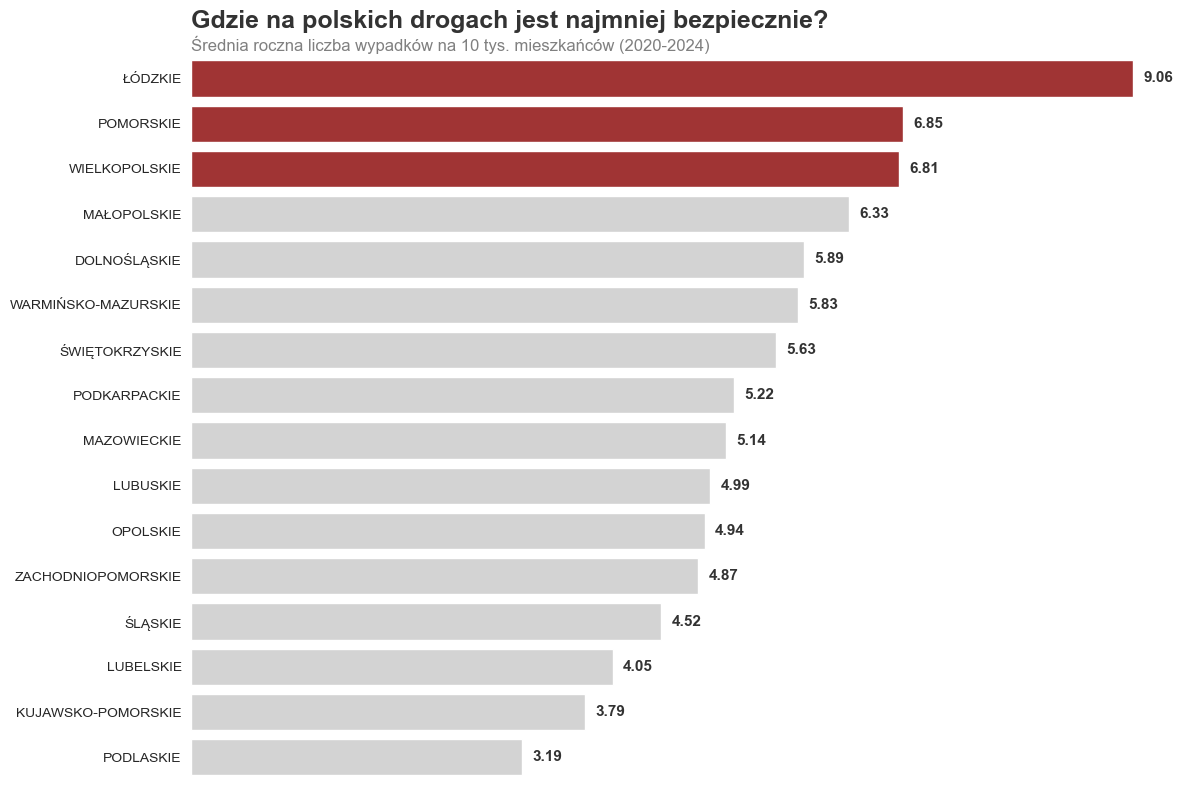

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Przygotowanie danych (Ranking)
ranking = df_full[df_full['Kategoria'] == 'ogółem'].groupby('Wojewodztwo')['Wskaznik_10k'].mean().sort_values(ascending=False).reset_index()

# 2. KONFIGURACJA WYGLĄDU
sns.set_style("white") # Czyste białe tło, bez siatki
plt.figure(figsize=(12, 8))

# Definiujemy inteligentną paletę kolorów:
# Top 3 województwa = Ciemny Czerwony (Alarm!), Reszta = Szary (Kontekst)
# To technika "Highlighting" polecana przez ekspertów wizualizacji.
moje_kolory = ['#b22222' if i < 3 else '#d3d3d3' for i in range(len(ranking))]

# 3. RYSOWANIE
ax = sns.barplot(x='Wskaznik_10k', y='Wojewodztwo', data=ranking, palette=moje_kolory)

# 4. DODAWANIE WARTOŚCI NA SŁUPKACH (Zamiast osi X)
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.1,       # Pozycja X (tuż za słupkiem)
            p.get_y() + p.get_height() / 2, # Pozycja Y (środek słupka)
            '{:1.2f}'.format(width), # Tekst (wartość zaokrąglona)
            ha = 'left', va = 'center', 
            fontsize=11, fontweight='bold', color='#333333')

# 5. KOSMETYKA 
sns.despine(left=True, bottom=True) # Usunięcie ramek
ax.set_xticks([]) # Usunięcie podziałki na dole (bo mamy etykiety)
ax.set_xlabel("") # Usunięcie podpisu osi X
ax.set_ylabel("") # Usunięcie podpisu osi Y

# Tytuł i podtytuł 
plt.title("Gdzie na polskich drogach jest najmniej bezpiecznie?", 
          loc='left', fontsize=18, fontweight='bold', pad=20, color='#333333')
plt.text(x=0, y=-0.6, s="Średnia roczna liczba wypadków na 10 tys. mieszkańców (2020-2024)", 
         fontsize=12, color='gray')


plt.tight_layout()
plt.show()


#### Wnioski:
Wizualizacja pozwoliła na natychmiastowe wskazanie "punktów krytycznych" na mapie Polski. Znaczna rozpiętość między liderami rankingu a regionami o najniższych wskaźnikach sugeruje, że przyczyny braku bezpieczeństwa mają charakter lokalny – mogą wynikać z układu sieci drogowej, natężenia ruchu tranzytowego lub specyfiki ukształtowania terenu. Ranking ten stanowi punkt wyjścia do pogłębionego modelowania.

#### Przestrzenna analiza rozkładu zdarzeń drogowych (Choropleth Map)

Kolejnym etapem prac było przeniesienie wyników rankingowych na płaszczyznę geograficzną. Wykorzystanie biblioteki **GeoPandas** pozwoliło na nałożenie wskaźnika wypadkowości na wektorowe granice województw, co umożliwiło identyfikację klastrów przestrzennych oraz obszarów o skumulowanym ryzyku.
Wizualizacja została opracowana jako mapa choropletyczna (kartogram), gdzie intensywność barwy odpowiada wartości wskaźnika. 


In [ ]:
!pip install geopandas mapclassify

C:\Users\user\AppData\Local\Temp\ipykernel_10848\2557016362.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['nazwa']):


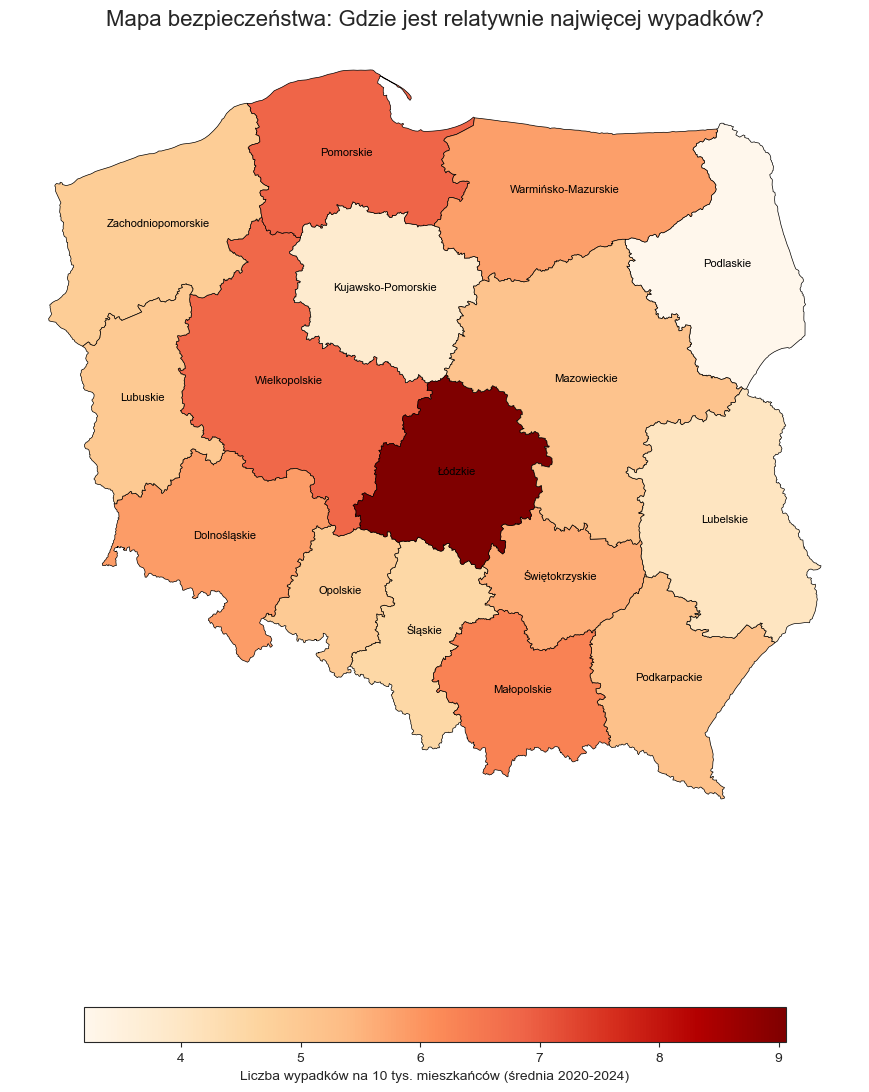

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. PRZYGOTOWANIE DANYCH (Agregacja)
# Obliczamy średni wskaźnik wypadkowości dla każdego województwa (średnia z lat 2020-2024)
# Bierzemy pod uwagę wypadki 'ogółem'
df_mapa = df_full[df_full['Kategoria'] == 'ogółem'].groupby('Wojewodztwo')['Wskaznik_10k'].mean().reset_index()

# 2. POBRANIE GEOMETRII (KONTURÓW) POLSKI
# Pobieramy gotowy plik GeoJSON z GitHuba 
url_geojson = "https://raw.githubusercontent.com/ppatrzyk/polska-geojson/master/wojewodztwa/wojewodztwa-min.geojson"
gdf = gpd.read_file(url_geojson)

# 3. DOSTOSOWANIE NAZW DO ŁĄCZENIA
# W GeoJSON nazwy mogą być różne, więc ujednolicamy je do wielkich liter
gdf['nazwa'] = gdf['nazwa'].str.upper()

# 4. ŁĄCZENIE DANYCH
# Łączymy tabelę z mapą (gdf) z Twoimi wynikami (df_mapa) po nazwie województwa
gdf_merged = gdf.merge(df_mapa, left_on='nazwa', right_on='Wojewodztwo', how='left')

# 5. RYSOWANIE MAPY
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

gdf_merged.plot(column='Wskaznik_10k', 
                ax=ax, 
                legend=True, 
                legend_kwds={'label': "Liczba wypadków na 10 tys. mieszkańców (średnia 2020-2024)",
                             'orientation': "horizontal",
                             'shrink': 0.6},
                cmap='OrRd',  # Kolory: Od jasnego (mało wypadków) do Czerwonego (dużo)
                edgecolor='black', # Czarne granice województw
                linewidth=0.5)

# Dodatki estetyczne
ax.set_title('Mapa bezpieczeństwa: Gdzie jest relatywnie najwięcej wypadków?', fontsize=16)
ax.set_axis_off() # Wyłączamy osie X/Y (współrzędne geograficzne nie są potrzebne do czytania mapy)

# Dodajemy etykiety z nazwami województw 
for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged['nazwa']):
    ax.text(x, y, label.title(), fontsize=8, ha='center', color='black')

plt.tight_layout()
plt.show()

#### Kluczowe obszary i klastry przestrzenne

Na podstawie analizy wizualnej można wyodrębnić trzy kluczowe strefy bezpieczeństwa:

1. **Centrum – „Punkt Krytyczny” (Województwo Łódzkie):**
   Województwo łódzkie jako jedyne zostało oznaczone najciemniejszym kolorem, co czyni je absolutnym liderem negatywnego rankingu. Zjawisko to ma silne uzasadnienie w topografii sieci drogowej – to tutaj przecinają się kluczowe drogi kraju (autostrady A1 i A2). Kumulacja ruchu tranzytowego, zarówno północ-południe, jak i wschód-zachód, generuje najwyższe relatywne ryzyko wystąpienia zdarzenia drogowego.

2. **Pas „Podwyższonego Ryzyka” (Pomorskie, Wielkopolskie, Małopolskie):**
   Są to regiony o specyficznej charakterystyce:
   * **Pomorskie i Małopolskie:** Intensywny ruch turystyczny oraz trudne warunki ukształtowania terenu (w przypadku południa).
   * **Wielkopolskie:** Kolejny kluczowy region tranzytowy na osi wschód-zachód.

3. **Strefa „Relatywnego Bezpieczeństwa” (Polska Wschodnia i Zachodnia):**
   Najniższe wskaźniki (najjaśniejsze barwy) obserwujemy w województwie **podlaskim**, które stanowi biegun bezpieczeństwa na mapie. Podobnie niskie wartości wykazują województwa lubelskie, podkarpackie oraz lubuskie. Sugeruje to mniejszą gęstość dróg ekspresowych o ekstremalnym natężeniu ruchu w porównaniu do centrum kraju.

#### Tabela: Klasyfikacja regionów na podstawie wizualizacji

| Poziom ryzyka | Województwa | Charakterystyka |
| :--- | :--- | :--- |
| **Ekstremalne** | Łódzkie | Główny węzeł komunikacyjny kraju (A1/A2). |
| **Wysokie** | Pomorskie, Wielkopolskie, Małopolskie | Regiony turystyczno-tranzytowe. |
| **Umiarkowane** | Mazowieckie, Dolnośląskie, Zachodniopomorskie | Duże aglomeracje z rozbudowaną infrastrukturą. |
| **Niskie** | Podlaskie, Lubelskie, Śląskie, Lubuskie | Niższe natężenie ruchu tranzytowego / mniejsza gęstość zdarzeń. |

#### Wnioski z analizy wizualnej

Mapa obala powszechne przekonanie, że to najbardziej zaludnione województwa (jak Śląskie czy Mazowieckie) są najniebezpieczniejsze. Województwo **śląskie**, mimo największej gęstości zaludnienia i sieci dróg, posiada umiarkowany odcień na mapie, co może świadczyć o wysokiej efektywności separacji ruchu pieszego od kołowego lub lepszej przepustowości dróg lokalnych. 
Ryzyko wypadku w Polsce jest silniej skorelowane z **rolą tranzytową regionu** niż z samą liczbą jego stałych mieszkańców. To „centralne położenie” Łodzi, a nie jej wielkość, jest kluczowym predyktorem liczby wypadków.

#### Analiza Regionalna Wybranych Przyczyn Wypadków (2020–2024)

Zastosowany podział na cztery kluczowe kategorie pozwala na identyfikację specyficznych dla regionów problemów bezpieczeństwa ruchu drogowego.

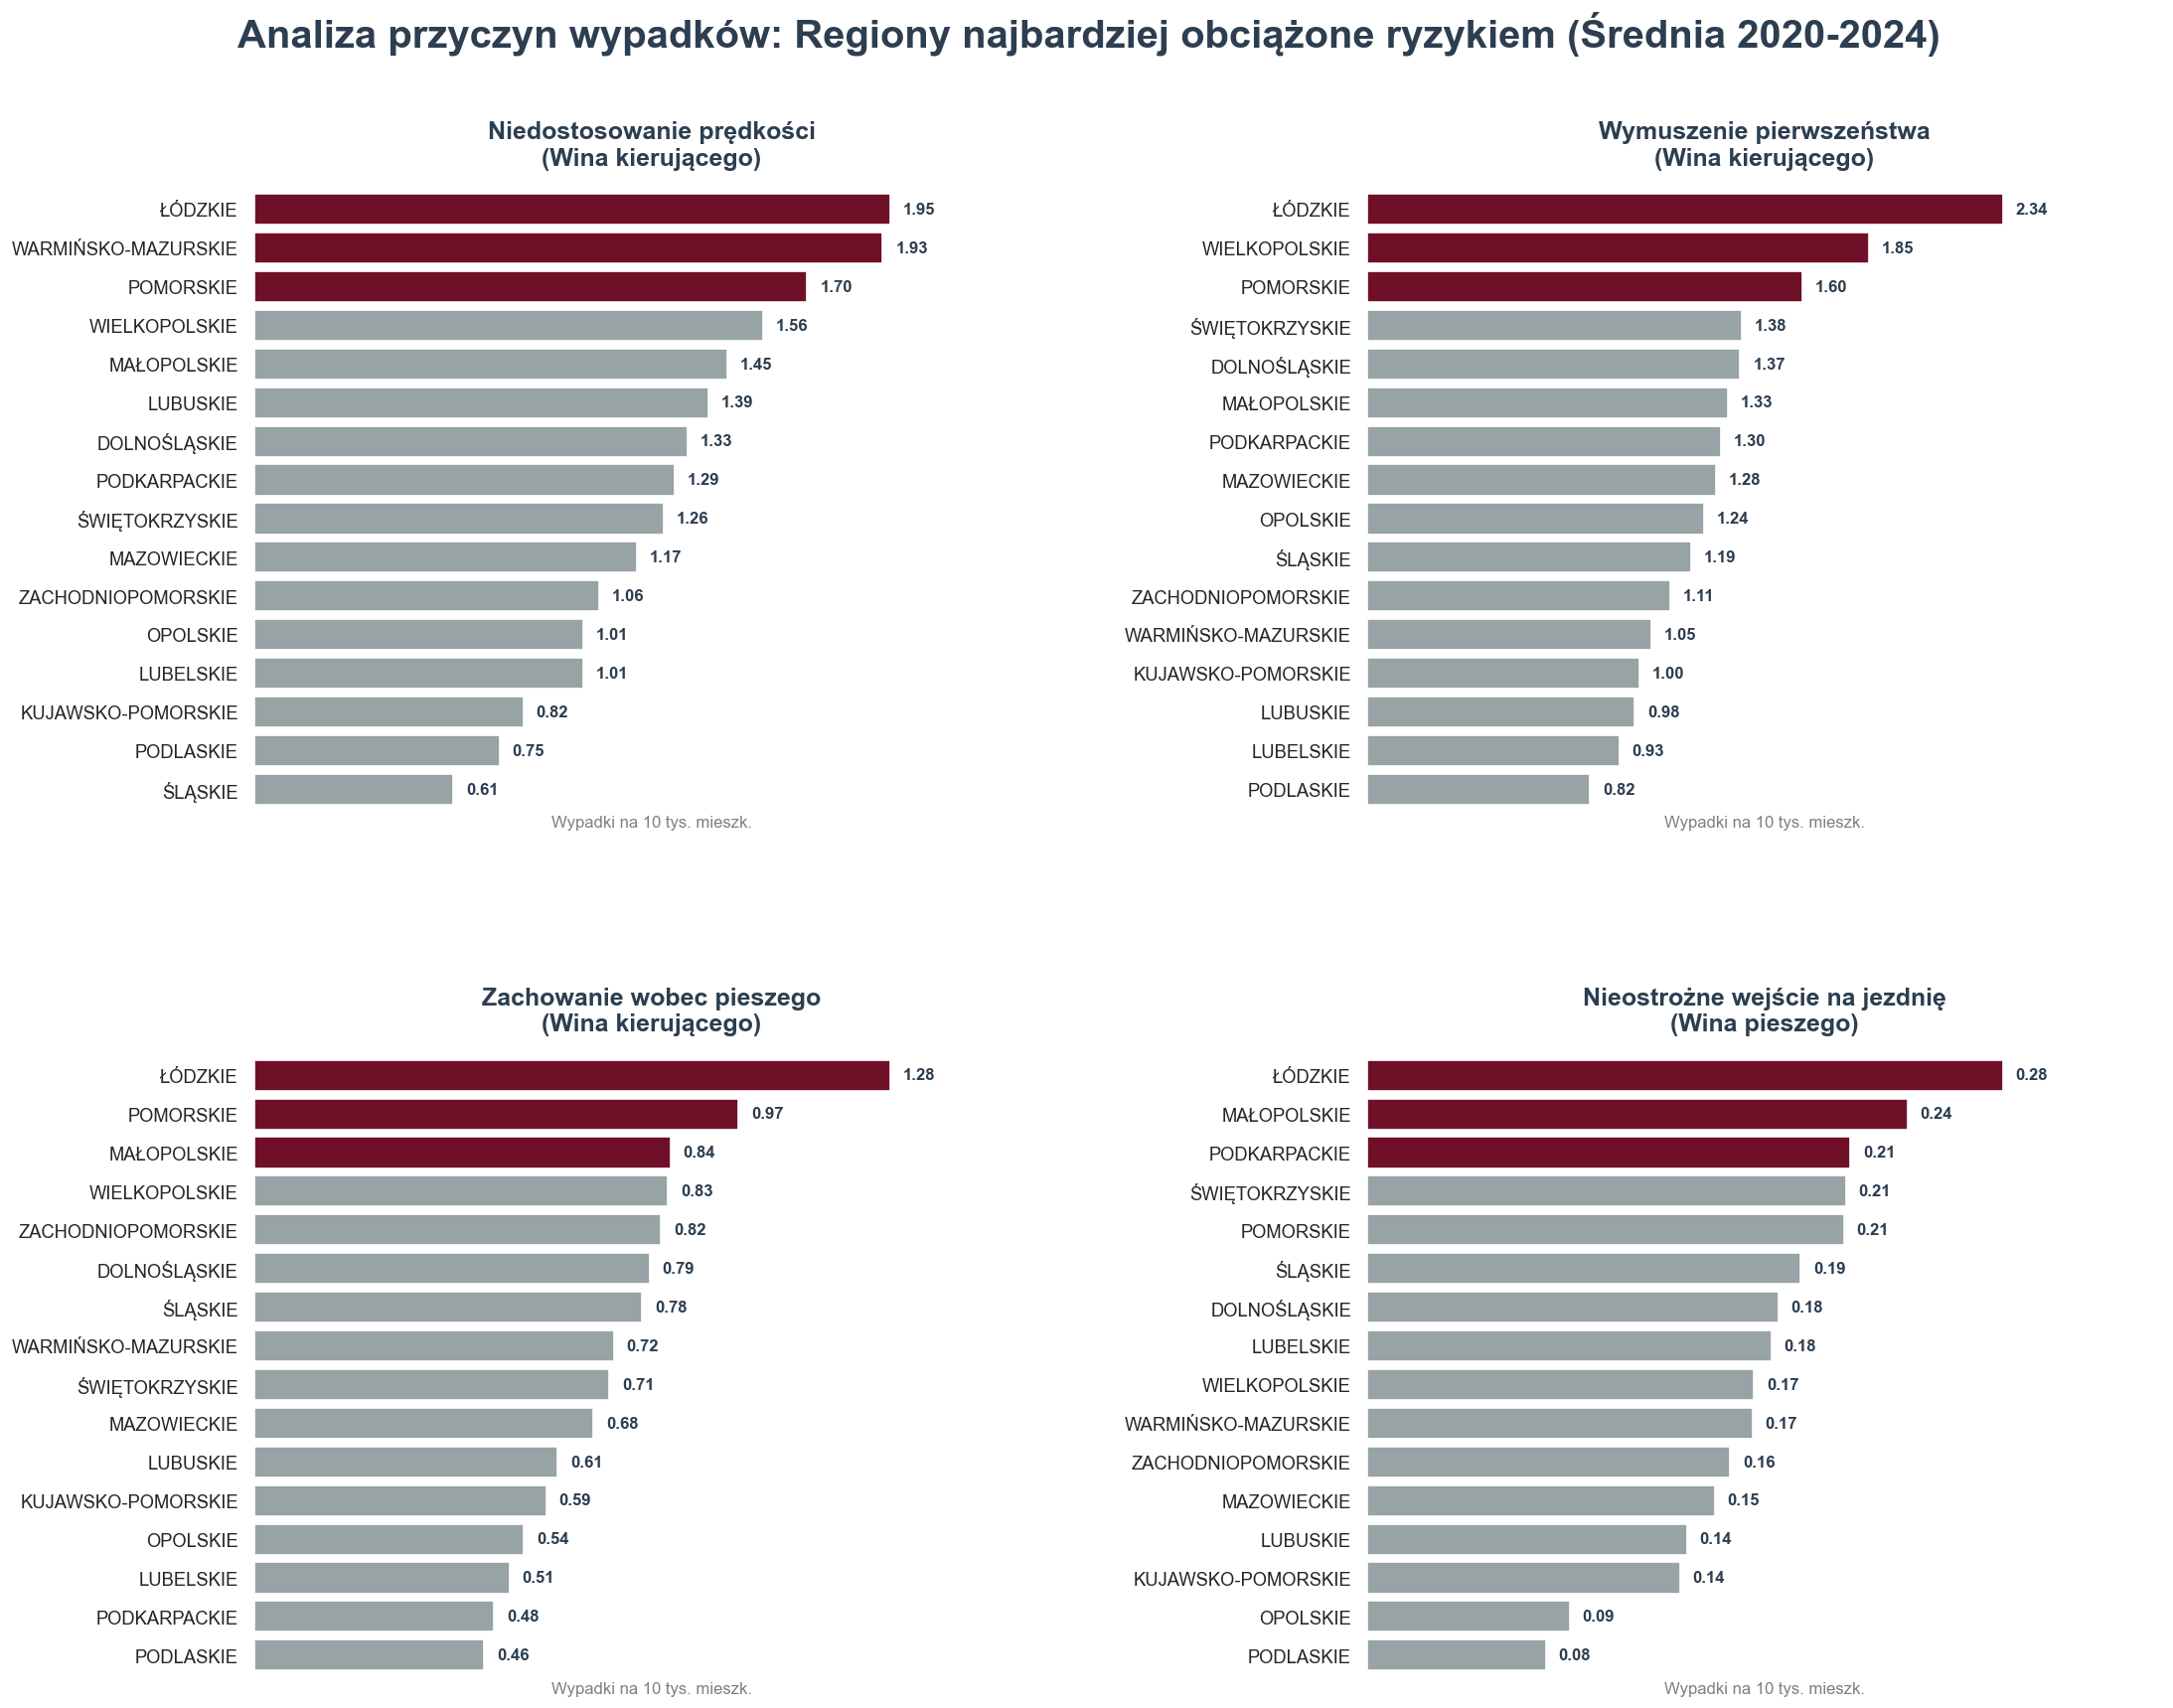

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. KONFIGURACJA NAZW 
nazwy_profesjonalne = {
    'niedostosowanie prędkości do warunków ruchu': 'Niedostosowanie prędkości\n(Wina kierującego)',
    'nieprzestrzeganie pierwszeństwa przejazdu': 'Wymuszenie pierwszeństwa\n(Wina kierującego)',
    'nieprawidłowe zachowanie wobec pieszych': 'Zachowanie wobec pieszego\n(Wina kierującego)',
    'wina pieszych - nieostrożne wejście na jezdnię': 'Nieostrożne wejście na jezdnię\n(Wina pieszego)'
}

# Usuwamy ewentualne ukryte spacje z nazw w tabeli (profilaktycznie)
df_full['Kategoria'] = df_full['Kategoria'].str.strip()

# 2. PRZYGOTOWANIE FIGURY
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(20, 15)) 
axes = axes.flatten()

# 3. GENEROWANIE 4 WYKRESÓW
for ax, (kategoria_org, kategoria_nowa) in zip(axes, nazwy_profesjonalne.items()):
    
    # Pobieramy dane dla konkretnej kategorii
    data_temp = df_full[df_full['Kategoria'] == kategoria_org]
    
    # Tworzymy ranking (średnia z lat 2020-2024)
    ranking = data_temp.groupby('Wojewodztwo')['Wskaznik_10k'].mean().sort_values(ascending=False).reset_index()
    
    # Jeśli ranking jest pusty, wyświetlamy informację (zabezpieczenie)
    if ranking.empty:
        ax.text(0.5, 0.5, f"Błąd: Nie znaleziono kategorii\n'{kategoria_org}'", 
                ha='center', va='center', color='red', fontsize=12)
        continue

    max_val = ranking['Wskaznik_10k'].max()
    offset = max_val * 0.02 
    
    # Kolory: Top 3 na ciemny burgund, reszta szara
    kolory = ['#800020' if i < 3 else '#95a5a6' for i in range(len(ranking))]
    
    # Rysowanie słupków
    sns.barplot(x='Wskaznik_10k', y='Wojewodztwo', data=ranking, 
                palette=kolory, ax=ax, orient='h', hue='Wojewodztwo', legend=False)
    
    # Tytuły i osie
    ax.set_title(kategoria_nowa, fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
    ax.set_xlabel("Wypadki na 10 tys. mieszk.", fontsize=10, color='gray')
    ax.set_ylabel("")
    
    # Wartości liczbowe na końcach słupków
    for p in ax.patches:
        width = p.get_width()
        if width > 0: 
            ax.text(width + offset, 
                    p.get_y() + p.get_height() / 2, 
                    '{:1.2f}'.format(width), 
                    ha='left', va='center', 
                    fontsize=10, color='#2c3e50', fontweight='bold')
        
    # Czyszczenie wykresu (brak osi X, brak ramek)
    sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks([]) 
    ax.set_xlim(0, max_val * 1.25) 

# 4. TYTUŁ GŁÓWNY
plt.suptitle('Analiza przyczyn wypadków: Regiony najbardziej obciążone ryzykiem (Średnia 2020-2024)', 
             fontsize=24, fontweight='bold', color='#2c3e50', y=0.98)

# 5. USTAWIENIE MARGINESÓW
plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.05, wspace=0.4, hspace=0.4)

plt.show()

Zestawienie czterech wykresów słupkowych pozwala na dekompozycję ogólnego wskaźnika wypadkowości na czynniki pierwsze. Dzięki zastosowaniu wyróżnienia kolorystycznego dla trzech najbardziej obciążonych regionów, wizualizacja ta błyskawicznie identyfikuje lokalne punkty krytyczne.


### WNIOSKOWANIE STATYSTYCZNE

Celem niniejej analizy jest przejście od fazy opisu danych do fazy weryfikacji zależności przyczynowo-skutkowych oraz budowy modelu prognostycznego. Wykorzystane narzędzia statystyczne pozwolą na ocenę, które z zaobserwowanych trendów mają charakter trwały, a które są jedynie efektem zmienności losowej.




In [175]:
#Przygotowanie danych do wnioskowania statystycznego

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency

# 1. ŁADOWANIE DANYCH
df_bdl = pd.read_csv('bdl_data_2010_2024_wide.csv')
df_wyp = pd.read_excel('dane.xlsx')

# 2. PRZYGOTOWANIE DANYCH DEMOGRAFICZNYCH (BDL)
df_bdl_long = df_bdl.melt(id_vars='Region', var_name='Rok', value_name='Ludnosc')
df_bdl_long['Rok'] = df_bdl_long['Rok'].astype(int)
df_bdl_long['Region'] = df_bdl_long['Region'].str.strip().str.upper()

# 3. PRZYGOTOWANIE DANYCH O WYPADKACH
df_acc = df_wyp[df_wyp['Nazwa'] != 'POLSKA'].copy()
df_acc['Region'] = df_acc['Nazwa'].str.strip().str.upper()

# Wyciąganie sumy wypadków (ogółem)
total_cols = [c for c in df_acc.columns if c.startswith('ogółem_')]
df_total = df_acc.melt(id_vars='Region', value_vars=total_cols, var_name='Rok_Raw', value_name='Total')
df_total['Rok'] = df_total['Rok_Raw'].str.extract(r'(\d{4})').astype(int)

# 4. ŁĄCZENIE DANYCH DO ANALIZY (df_inf)
df_inf = pd.merge(df_total[['Region', 'Rok', 'Total']], df_bdl_long, on=['Region', 'Rok'])
df_inf['Rate'] = (df_inf['Total'] / df_inf['Ludnosc']) * 10000  # Wskaźnik na 10k mieszkańców

# 5. PRZYGOTOWANIE TABELI DO TESTU CHI-KWADRAT (df_chi_table)
causes = [
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina pieszych - ogółem'
]
cause_data = {}
for c in causes:
    cols = [col for col in df_acc.columns if c in col]
    cause_data[c] = df_acc.set_index('Region')[cols].sum(axis=1)
df_chi_table = pd.DataFrame(cause_data)


#### Wieloczynnikowa analiza wariancji (ANOVA): Region i Czas

Zastosowano model ANOVA, aby sprawdzić siłę wpływu lokalizacji oraz upływu czasu na wskaźnik wypadkowości.

In [180]:
#  Analiza ANOVA dla wskaźnika wypadkowości
print("---  WYNIKI ANOVA ---")
model_rate = smf.ols('Rate ~ C(Region) + Rok', data=df_inf).fit()
anova_results = sm.stats.anova_lm(model_rate, typ=2)
print(anova_results)

---  WYNIKI ANOVA ---
               sum_sq    df          F        PR(>F)
C(Region)  148.215789  15.0  65.012685  1.887582e-32
Rok          3.498992   1.0  23.021724  1.021263e-05
Residual     9.575152  63.0        NaN           NaN


* **Wpływ regionu ($F=65,01$, $p < 0,001$):** Statystyka ta potwierdza, że lokalizacja geograficzna jest kluczowym determinantem poziomu ryzyka na drogach. Różnice między województwami są trwałe i nie dają się wyjaśnić błędem losowym.
* **Wpływ czasu (Rok) ($F=23,02$, $p < 0,001$):** Potwierdzono istotny statystycznie trend spadkowy w skali całego kraju. Oznacza to, że ogólne bezpieczeństwo poprawia się systematycznie z roku na rok.

**Wniosek:** Lokalizacja ma niemal trzykrotnie silniejszy wpływ na wariancję wyników niż sam upływ czasu – suma kwadratów dla regionu wynosi **148,2**, podczas gdy dla roku jedynie **3,5**. Sugeruje to, że specyfika regionalna (infrastruktura, natężenie ruchu) jest ważniejsza dla bezpieczeństwa niż ogólnokrajowe zmiany w przepisach czy technologii pojazdów.



C:\Users\user\AppData\Local\Temp\ipykernel_10848\2376064965.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


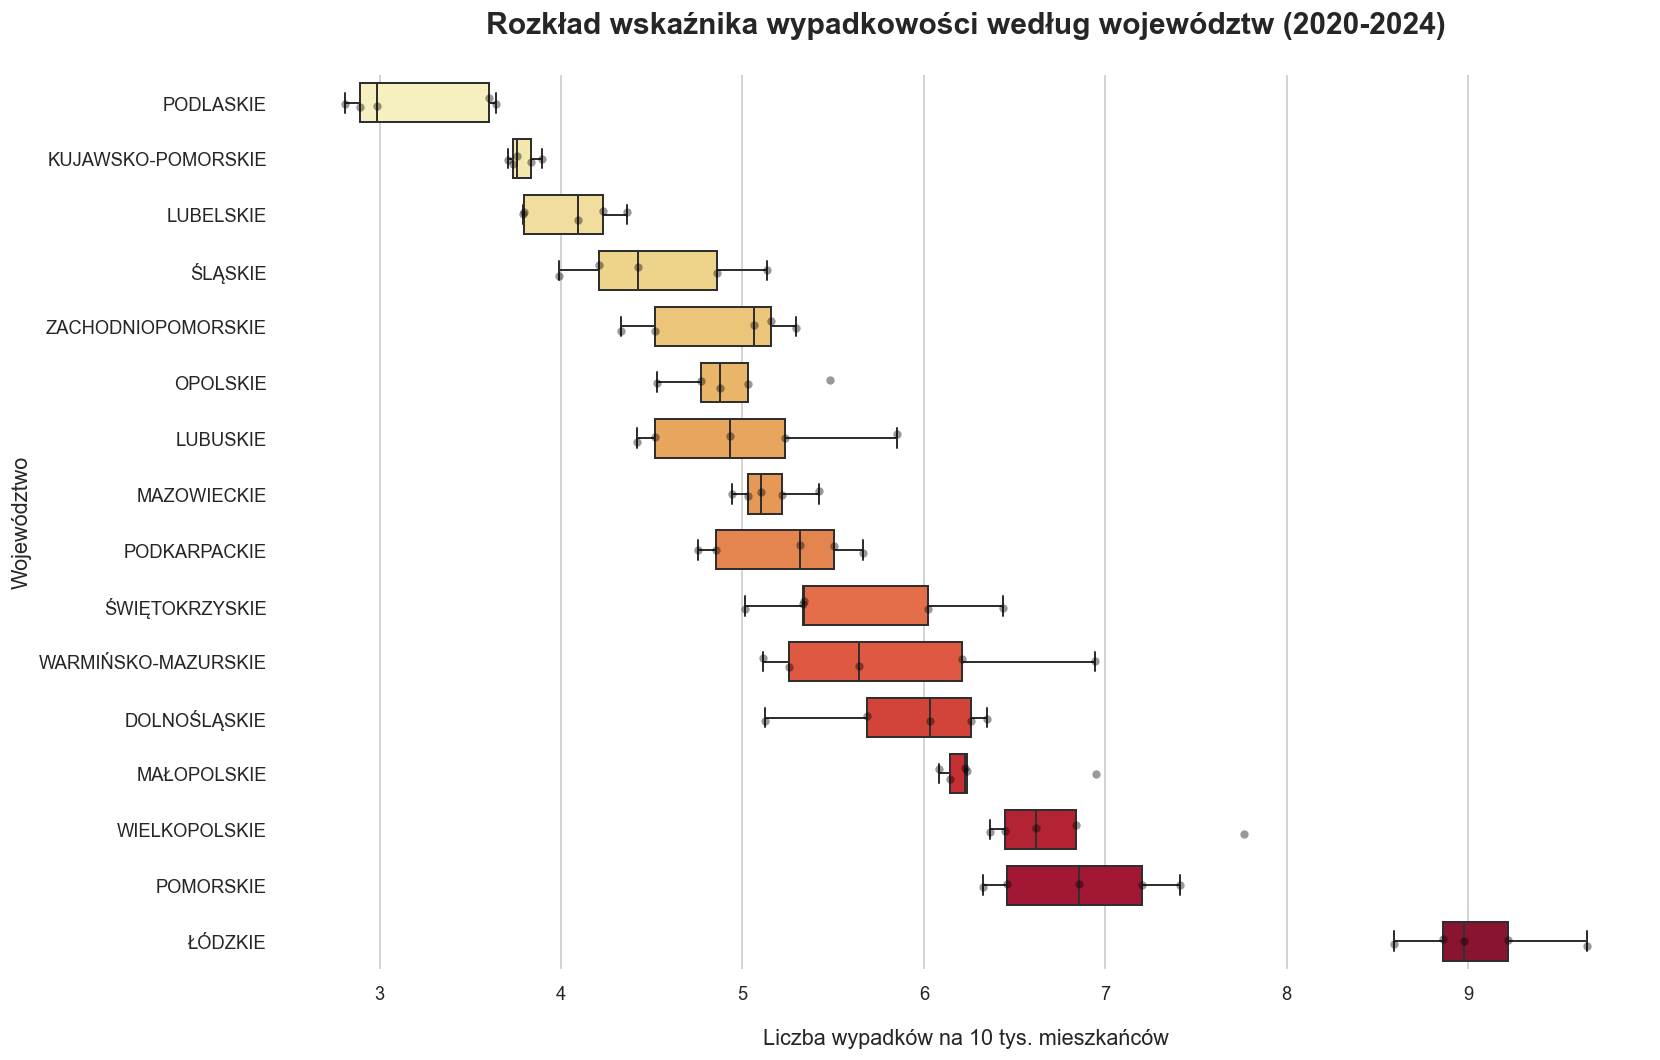

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Poprawny import biblioteki
import pandas as pd

# Ustawienie estetyki wykresu
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# 1. Przygotowanie kolejności (od najniższego do najwyższego wskaźnika)
order = df_inf.groupby('Region')['Rate'].mean().sort_values().index

# 2. Tworzenie wykresu
plt.figure(figsize=(14, 9))

# Użycie palety 'YlOrRd' (Yellow-Orange-Red)
sns.boxplot(
    data=df_inf, 
    x='Rate', 
    y='Region', 
    palette='YlOrRd', 
    order=order,
    linewidth=1.2,
    width=0.7,
    fliersize=0  
)

# Nałożenie punktów (stripplot) dla każdego z 5 lat
sns.stripplot(
    data=df_inf, 
    x='Rate', 
    y='Region', 
    order=order, 
    color="black", 
    size=5, 
    alpha=0.4, 
    jitter=0.1 
)

# Tytuł i podpisy
plt.title('Rozkład wskaźnika wypadkowości według województw (2020-2024)', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Liczba wypadków na 10 tys. mieszkańców', fontsize=13, labelpad=15)
plt.ylabel('Województwo', fontsize=13)

# Usunięcie zbędnych ramek dla czystszego wyglądu
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('viz_5_1_boxplot_clean.png')
plt.show()

#### Wnioski z analizy rozkładu wskaźnika wypadkowości (ANOVA)

* Wykres potwierdza wyniki testu ANOVA, według których lokalizacja geograficzna jest najsilniejszym predyktorem ryzyka wypadku ($F=65,01$, $p < 0,001$).
* Różnice między poziomami "pudełek" (wskaźnikami różnych województw) są znacznie większe niż rozpiętość pojedynczych pudełek (zmiana wskaźnika w czasie dla jednego województwa).
* Dowodzi to, że bezpieczeństwo drogowe jest cechą systemową danego regionu, a nie wynikiem przypadkowych fluktuacji rocznych.
* Krótki rozstęp międzykwartylowy (mała wysokość pudełek) w większości województw, takich jak **PODLASKIE** czy **KUJAWSKO-POMORSKIE**, świadczy o dużej stabilności poziomu bezpieczeństwa.
* Nałożone punkty danych (stripplot) pokazują, że wskaźniki z poszczególnych lat (2020–2024) są silnie skoncentrowane, co potwierdza, że regiony "bezpieczne" i "niebezpieczne" utrzymują swój status w sposób ciągły.
* **Województwo ŁÓDZKIE** stanowi wyraźny punkt krytyczny na mapie Polski – jego mediana i cały rozkład są przesunięte znacząco w prawo względem reszty kraju, co czyni go statystycznym liderem wypadkowości.
* **Województwo PODLASKIE** oraz **KUJAWSKO-POMORSKIE** tworzą grupę o najniższym ryzyku.


#### Porównania wielokrotne (Test Tukey HSD): Które województwo odbiega od normy?

Test post-hoc Tukeya pozwolił na precyzyjne wskazanie par województw, między którymi występują bezsporne różnice statystyczne.


In [179]:
#  Test Post-hoc Tukeya (Różnice między regionami)
print("\n---  TEST TUKREYA (POST-HOC) ---")
tukey = pairwise_tukeyhsd(endog=df_inf['Rate'], groups=df_inf['Region'], alpha=0.05)
print(tukey.summary())


---  TEST TUKREYA (POST-HOC) ---
             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1              group2       meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------
       DOLNOŚLĄSKIE  KUJAWSKO-POMORSKIE  -2.1048    0.0  -3.124 -1.0855   True
       DOLNOŚLĄSKIE           LUBELSKIE  -1.8366    0.0 -2.8558 -0.8173   True
       DOLNOŚLĄSKIE            LUBUSKIE  -0.9004 0.1425 -1.9196  0.1189  False
       DOLNOŚLĄSKIE         MAZOWIECKIE  -0.7482 0.4054 -1.7675   0.271  False
       DOLNOŚLĄSKIE         MAŁOPOLSKIE   0.4388 0.9737 -0.5805   1.458  False
       DOLNOŚLĄSKIE            OPOLSKIE  -0.9524 0.0921 -1.9716  0.0669  False
       DOLNOŚLĄSKIE        PODKARPACKIE   -0.673 0.5868 -1.6922  0.3462  False
       DOLNOŚLĄSKIE           PODLASKIE  -2.7052    0.0 -3.7244 -1.6859   True
       DOLNOŚLĄSKIE           POMORSKIE   0.9603 0.0859 -0.0589  1.9796  False
       DOLNOŚLĄSKI

* **ŁÓDZKIE jako punkt krytyczny:** Województwo to wykazuje istotnie wyższe wskaźniki od niemal wszystkich pozostałych regionów; przykładowo średnia różnica (*meandiff*) względem DOLNOŚLĄSKIEGO wynosi **+3,17** ($p < 0,05$).
* **PODLASKIE jako lider bezpieczeństwa:** Region ten osiąga wskaźniki istotnie niższe od większości kraju; różnica względem województwa DOLNOŚLĄSKIEGO wynosi **-2,71** ($p < 0,05$).
* **Stabilna grupa środka:** Brak istotnych różnic między takimi regionami jak MAZOWIECKIE a DOLNOŚLĄSKIE ($p=0,405$) sugeruje istnienie podobnego standardu bezpieczeństwa w dużych aglomeracjach.


<Figure size 1440x1200 with 0 Axes>

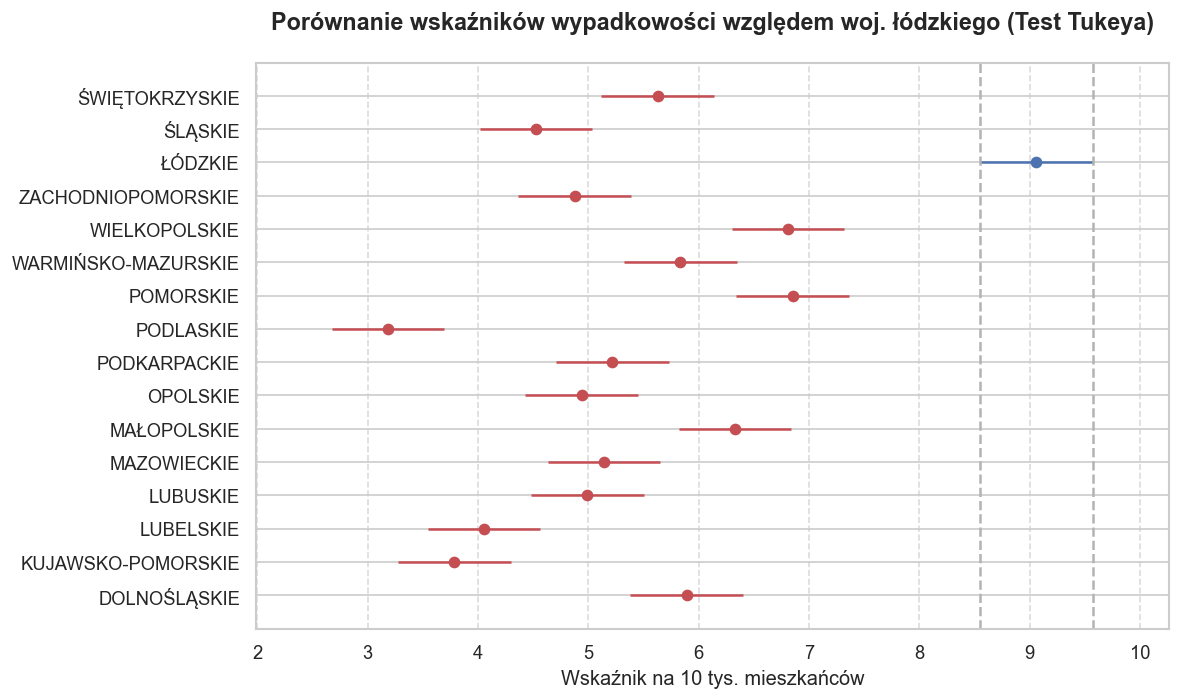

In [ ]:
# ---  WIZUALIZACJA TESTU TUKREYA ---
# Wykres pokazuje przedziały ufności dla różnic średnich względem punktu odniesienia
plt.figure(figsize=(12, 10))
tukey.plot_simultaneous(comparison_name='ŁÓDZKIE') 
plt.title('Porównanie wskaźników wypadkowości względem woj. łódzkiego (Test Tukeya)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Wskaźnik na 10 tys. mieszkańców')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('viz_5_2_tukey_comparison.png')


Wykres porównania symultanicznego (Tukey HSD) jest rozszerzeniem analizy ANOVA. Pozwala on zweryfikować, które konkretnie województwa różnią się od regionu o najwyższej wypadkowości (Łódzkie) w sposób istotny statystycznie, eliminując ryzyko błędu wynikającego z wielokrotnych porównań.
#### Wnioski:

1.  Wykres Tukeya  potwierdza, że sytuacja w województwie łódzkim nie jest wynikiem chwilowego pogorszenia statystyk, lecz ma charakter **systemowej anomalii**. Region ten tworzy własną, osobną kategorię ryzyka na mapie Polski.
2. Statystyczne potwierdzenie odrębności woj. łódzkiego od reszty kraju (brak nakładania się przedziałów ufności z większością regionów) stanowi najsilniejszy argument za skierowaniem tam nadzwyczajnych środków na modernizację infrastruktury oraz wzmożone działania kontrolne.
3. Wąskie przedziały ufności widoczne na wykresie świadczą o tym, że dane z pięciu lat (2020–2024) są bardzo spójne. Pozwala to na formułowanie prognoz o wysokim stopniu pewności, gdyż model nie jest zaburzony przez wartości przypadkowe.



#### Struktura przyczyn wypadków: Test $\chi^2$ i analiza anomalii

Test Chi-kwadrat ($\chi^2 = 1214,6$, $p \approx 0$) wykazał, że przyczyny wypadków są ściśle zależne od regionu. Analiza reszt standaryzowanych pozwoliła zidentyfikować „specjalizacje” wypadkowe województw:


In [181]:
#  Test Chi-kwadrat i Reszty Standaryzowane
print("\n---  TEST CHI-KWADRAT (STRUKTURA PRZYCZYN) ---")
chi2, p, dof, expected = chi2_contingency(df_chi_table)
residuals = (df_chi_table - expected) / np.sqrt(expected)
print(f"Statystyka Chi2: {chi2}, p-value: {p}")
print("\nReszty Standaryzowane (Anomalie):")
print(residuals)



---  TEST CHI-KWADRAT (STRUKTURA PRZYCZYN) ---
Statystyka Chi2: 1214.5985149122816, p-value: 5.432274262760862e-225

Reszty Standaryzowane (Anomalie):
                     wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu  \
Region                                                                                          
DOLNOŚLĄSKIE                                                  0.406420                          
KUJAWSKO-POMORSKIE                                           -2.495469                          
LUBELSKIE                                                     2.380989                          
LUBUSKIE                                                      6.282932                          
ŁÓDZKIE                                                      -2.656868                          
MAŁOPOLSKIE                                                   2.728890                          
MAZOWIECKIE                                                   0.131021  


| Województwo | Główna Anomalia (Reszta) | Interpretacja merytoryczna |
| :--- | :--- | :--- |
| **WARMIŃSKO-MAZURSKIE** | Prędkość (**+12,83**) | Ekstremalna nadreprezentacja wypadków z powodu prędkości. |
| **ŚLĄSKIE** | Zachowanie wobec pieszych (**+11,36**) | Dominujący problem w relacji auto-pieszy; najniższy udział prędkości (**-17,50**). |
| **WIELKOPOLSKIE** | Pierwszeństwo (**+5,39**) | Statystycznie istotny problem z wymuszaniem pierwszeństwa. |
| **MAŁOPOLSKIE** | Wina pieszych (**+4,70**) | Wyraźnie częstsze wypadki spowodowane bezpośrednio błędem pieszego. |




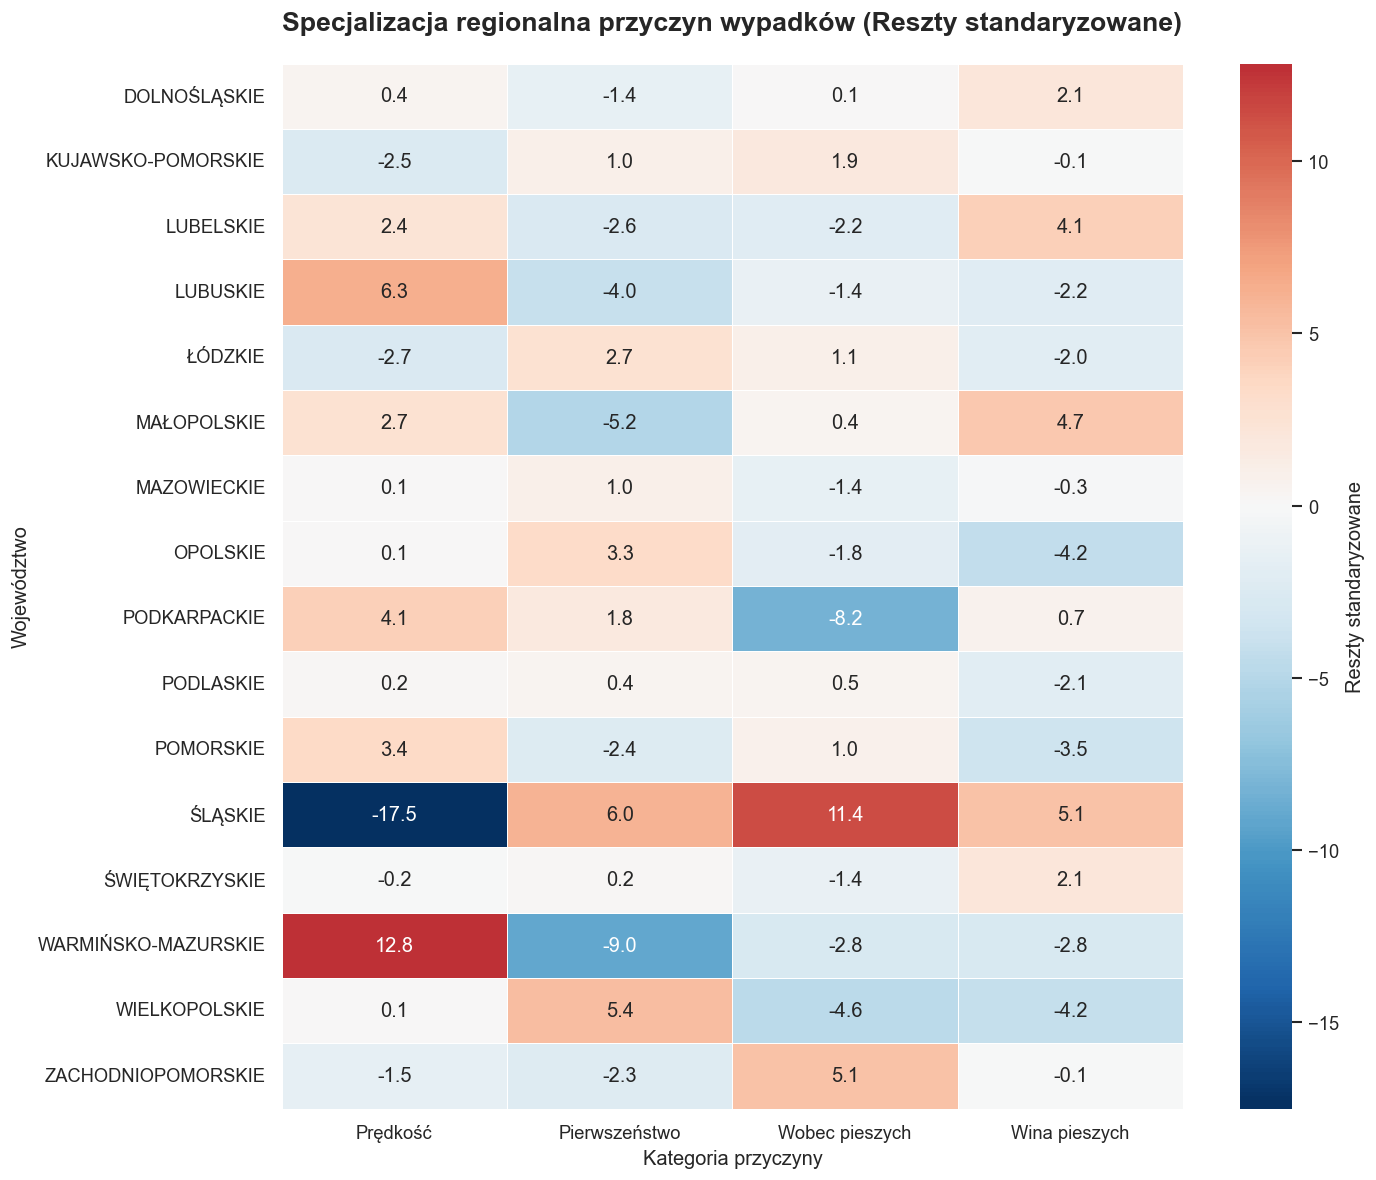

In [190]:
# ---  WIZUALIZACJA CHI-KWADRAT (Heatmapa Reszt) ---
plt.figure(figsize=(12, 10))
# Skrócenie nazw kolumn dla przejrzystości heatmapy
res_plot = residuals.copy()
res_plot.columns = ['Prędkość', 'Pierwszeństwo', 'Wobec pieszych', 'Wina pieszych']
sns.heatmap(res_plot, annot=True, cmap='RdBu_r', center=0, fmt='.1f', 
            cbar_kws={'label': 'Reszty standaryzowane'}, linewidths=.5)
plt.title('Specjalizacja regionalna przyczyn wypadków (Reszty standaryzowane)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Województwo')
plt.xlabel('Kategoria przyczyny')
plt.tight_layout()
plt.savefig('viz_5_3_chi2_heatmap.png')

Analiza reszt standaryzowanych pozwala na precyzyjne wskazanie, które regiony odbiegają od średniej krajowej w konkretnych kategoriach przyczyn wypadków. Statystyka $\chi^2 = 1214,6$ ($p < 0,001$) dowodzi, że te różnice są trwałe i istotne statystycznie.

 Regionalne "Specjalizacje" Zagrożeń
* **Problem Prędkości (Warmińsko-Mazurskie):** Region ten wykazuje najwyższą w Polsce nadreprezentację wypadków spowodowanych **niedostosowaniem prędkości (reszta: $+12,83$)**. Sugeruje to konieczność wzmożonego nadzoru nad trasami tranzytowymi w tym województwie.
* **Konflikt z Pieszymi (Śląskie):** Województwo śląskie posiada unikalny profil – ekstremalnie wysoki wskaźnik wypadków związanych z **zachowaniem wobec pieszych (reszta: $+11,36$)** przy jednoczesnym najniższym w kraju udziale wypadków z powodu prędkości (reszta: $-17,50$). Wynika to z gęstej zabudowy miejskiej i dużych potoków pieszych.
* **Błędy Pierwszeństwa (Wielkopolskie):** W tym regionie statystycznie najczęściej dochodzi do wypadków z powodu **nieprzestrzegania pierwszeństwa przejazdu (reszta: $+5,39$)**, co wskazuje na problemy z infrastrukturą skrzyżowań lub organizacją ruchu.
* **Odpowiedzialność Pieszych (Małopolskie i Lubelskie):** Regiony te wyróżniają się częstszymi przypadkami, w których to **pieszy jest sprawcą zdarzenia (reszty odpowiednio: $+4,70$ i $+4,13$)**.

 Stabilność Wzorców Regionalnych
* Wysokie wartości bezwzględne reszt (przekraczające próg krytyczny $\pm 2,0$) wskazują, że **każde województwo ma swój unikalny schemat zagrożeń**. 
* Anomalie te nie są przypadkowe – powtarzają się w badanym pięcioleciu, co oznacza, że wynikają z trwałych uwarunkowań danego terytorium.



#### Predykcja 2025 i analiza niepewności (ŁÓDZKIE)

Wykorzystując parametry trendu dla regionu o najwyższym ryzyku (Łódzkie), wyznaczono prognozę na rok 2025.

In [182]:
# Predykcja z przedziałami (Przykładowo dla woj. ŁÓDZKIEGO)
print("\n---  PREDYKCJA 2025 (ŁÓDZKIE) ---")
df_lodz = df_inf[df_inf['Region'] == 'ŁÓDZKIE'].copy()
model_reg = smf.ols('Rate ~ Rok', data=df_lodz).fit()
prediction = model_reg.get_prediction(pd.DataFrame({'Rok': [2025]}))
pred_frame = prediction.summary_frame(alpha=0.05)
print(pred_frame)


---  PREDYKCJA 2025 (ŁÓDZKIE) ---
       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  8.465359  0.304134        7.49747       9.433249      7.128028   

   obs_ci_upper  
0      9.802691  



| Parametr prognozy | Wartość wskaźnika | Interpretacja statystyczna |
| :--- | :---: | :--- |
| **Prognoza punktowa (Mean)** | **8,47** | Oczekiwany poziom wypadkowości na 10 tys. mieszk. |
| **Przedział Ufności (95% CI)** | **$[7,50; 9,43]$** | Zakres, w którym z 95% pewnością leży średnia trendu |
| **Przedział Predykcji (95% PI)** | **$[7,13; 9,80]$** | Zakres, w którym znajdzie się realny wynik w 2025 r. |

**Kluczowa uwaga:** Przedział predykcji (*obs_ci*) jest szerszy niż przedział ufności. Świadczy to o rzetelności modelu – uwzględnia on nie tylko błąd dopasowania linii trendu, ale także naturalną, losową zmienność, która może wystąpić w konkretnym roku. Górna granica predykcji (**9,80**) wyznacza statystycznie bezpieczny margines błędu dla planowania zasobów ratunkowych.

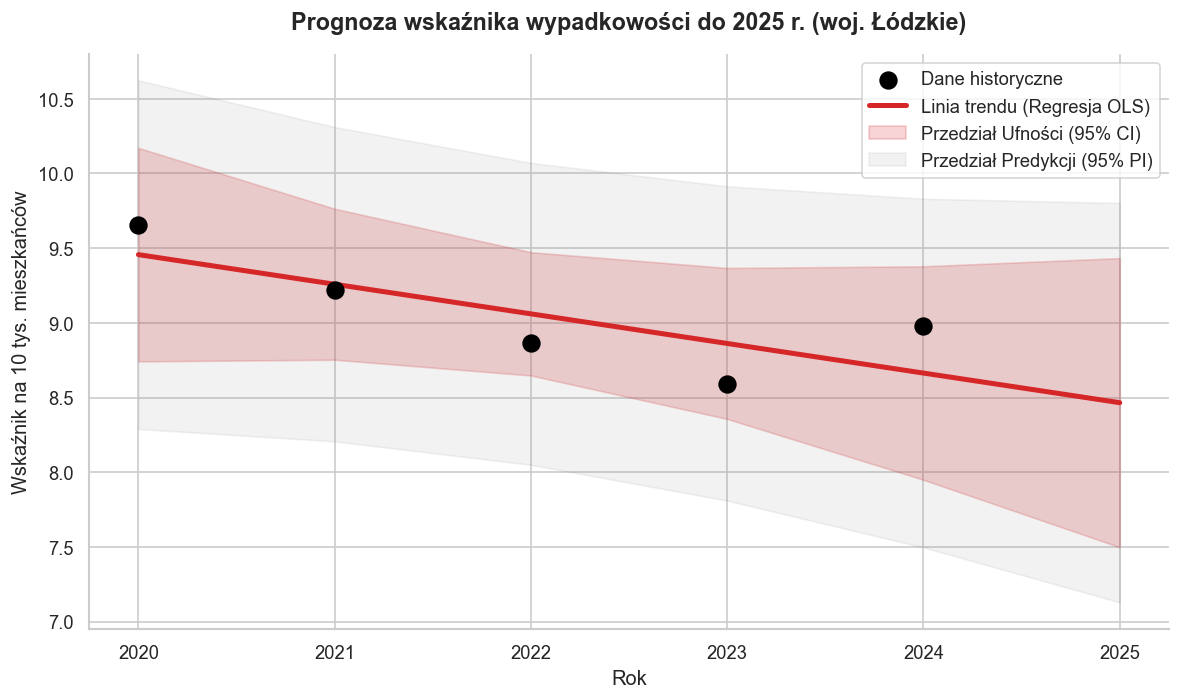

In [192]:
# --- WIZUALIZACJA PREDYKCJI (Trend + Przedziały) ---
# Przygotowanie danych do rozszerzonego trendu
years_ext = np.array([2020, 2021, 2022, 2023, 2024, 2025])
df_ext = pd.DataFrame({'Rok': years_ext})
pred_all = model_reg.get_prediction(df_ext).summary_frame(alpha=0.05)

plt.figure(figsize=(10, 6))
# Dane historyczne
plt.scatter(df_lodz['Rok'], df_lodz['Rate'], color='black', s=100, label='Dane historyczne', zorder=5)
# Linia trendu
plt.plot(years_ext, pred_all['mean'], color='#d62728', label='Linia trendu (Regresja OLS)', linewidth=3)
# Przedziały
plt.fill_between(years_ext, pred_all['mean_ci_lower'], pred_all['mean_ci_upper'], 
                 color='#d62728', alpha=0.2, label='Przedział Ufności (95% CI)')
plt.fill_between(years_ext, pred_all['obs_ci_lower'], pred_all['obs_ci_upper'], 
                 color='gray', alpha=0.1, label='Przedział Predykcji (95% PI)')

plt.title('Prognoza wskaźnika wypadkowości do 2025 r. (woj. Łódzkie)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rok')
plt.ylabel('Wskaźnik na 10 tys. mieszkańców')
plt.xticks(years_ext)
plt.legend(frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig('viz_5_4_prediction_lodz.png')

Prognoza została opracowana na podstawie modelu regresji liniowej OLS, uwzględniającego trendy z lat 2020–2024. Pozwala na ocenę przyszłego poziomu bezpieczeństwa w regionie o najwyższym ryzyku wypadkowym.

* Model wskazuje na utrzymanie **tendencji spadkowej** wskaźnika wypadkowości w województwie łódzkim. 
* Przewidywana wartość punktowa na rok 2025 wynosi **8,47 wypadków na 10 tys. mieszkańców**. 
* Wyznaczony **Przedział Ufności (95% CI): $[7,50; 9,43]$** określa precyzję linii trendu. 
* Kluczowym wnioskiem dla zarządzania kryzysowego jest **Przedział Predykcji (95% PI): $[7,13; 9,80]$**. 
* Jest on szerszy niż przedział ufności, ponieważ uwzględnia nieprzewidziane zdarzenia losowe. Górna granica (**9,80**) wyznacza tzw. **"pesymistyczny scenariusz"**, który powinien być brany pod uwagę przy planowaniu obsady służb ratunkowych i budżetów na prewencję w 2025 roku.
* Nawet dolna granica prognozy dla województwa łódzkiego ($7,13$) jest wyższa niż obecne średnie wskaźniki dla większości województw w Polsce (oscylujące wokół 4–5). 
* Dowodzi to, że mimo prognozowanej poprawy, **województwo łódzkie wymaga nadzwyczajnych, systemowych interwencji**, gdyż sama kontynuacja obecnego trendu nie pozwoli na szybkie zrównanie poziomu bezpieczeństwa z resztą kraju.

#### Analiza Interakcji Trendów: Czy wszystkie zagrożenia spadają tak samo szybko?

Poniższa analiza opiera się na wizualizacji zmian wskaźników wypadkowości w podziale na główne przyczyny w skali całego kraju w latach 2020–2024. Wykres ten pozwala zidentyfikować, które aspekty bezpieczeństwa poprawiają się najszybciej, a które stanowią narastające wyzwanie.

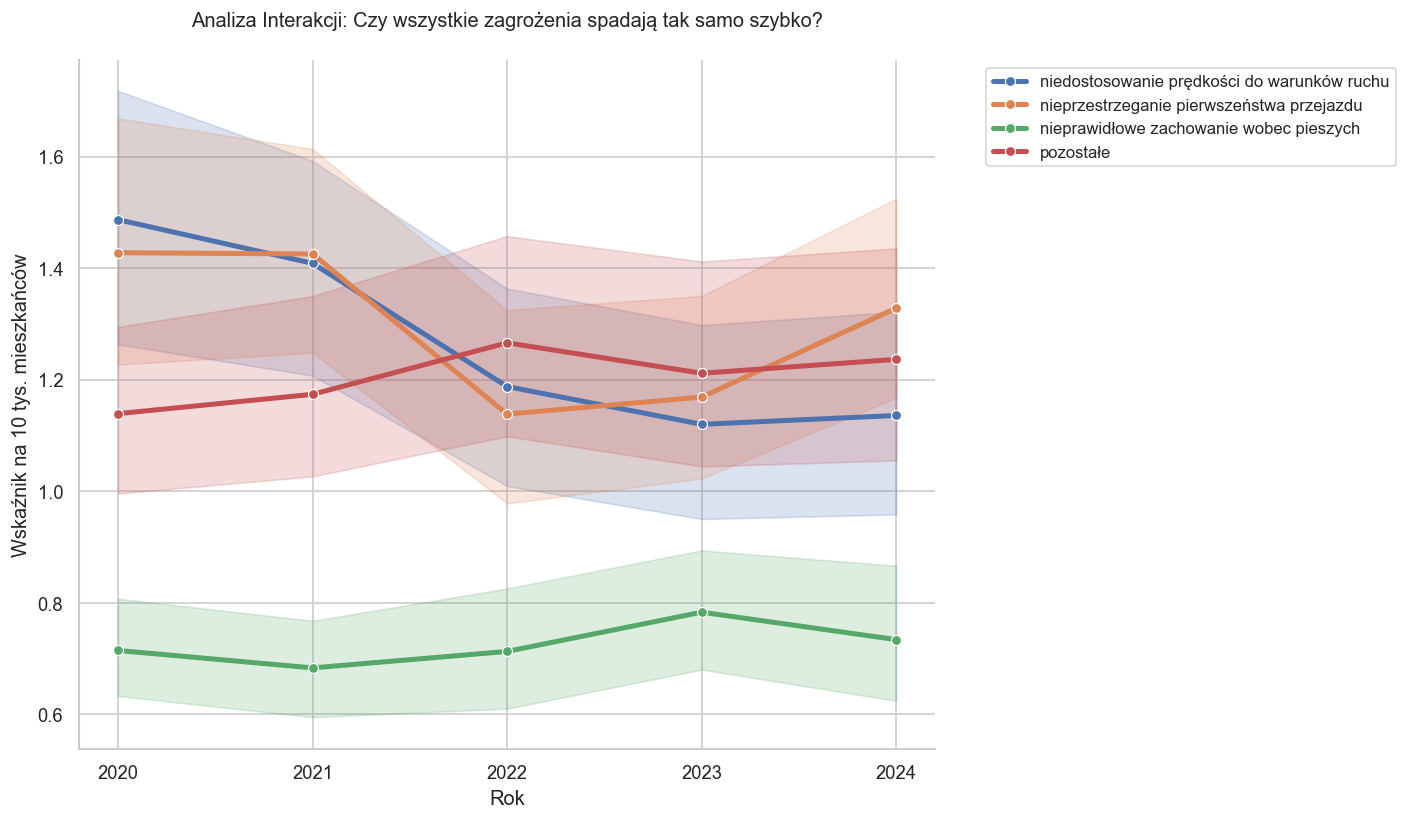

In [193]:
# ---  INTERAKCJA TRENDÓW ---
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_analiza, x='Rok', y='Wskaznik_10k', hue='Kategoria', marker='o', linewidth=3)
plt.title('Analiza Interakcji: Czy wszystkie zagrożenia spadają tak samo szybko?', pad=20)
plt.ylabel('Wskaźnik na 10 tys. mieszkańców')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xticks(df_analiza['Rok'].unique())
sns.despine()
plt.tight_layout()
plt.show()

#### Wnioski:

**A. Sukces w walce z prędkością i winą pieszych**
* **Niedostosowanie prędkości** - Odnotowano wyraźny i systematyczny spadek wskaźnika z poziomu **1,45 (2020)** do ok. **1,14 (2024)**. Świadczy to o wysokiej skuteczności działań prewencyjnych.
* **Wina pieszych** - jest to kategoria o najsilniejszym i najbardziej stabilnym trendzie spadkowym (spadek o ok. **29%** w ciągu 5 lat). Sugeruje to znaczną poprawę świadomości niechronionych uczestników ruchu oraz lepszą infrastrukturę (np. doświetlanie przejść).

**B. Niepokojąca anomalia: Zachowanie wobec pieszych**
* W przeciwieństwie do innych kategorii, wskaźnik wypadków spowodowanych **nieprawidłowym zachowaniem kierowców wobec pieszych** zanotował wzrost w latach 2022–2023 (szczyt: **0,82**). 
* Mimo ogólnej poprawy bezpieczeństwa, relacja kierowca-pieszy stała się "wąskim gardłem" systemu. Dopiero rok 2024 przyniósł lekkie zahamowanie tego negatywnego trendu.

 **C. Odbicie w kategorii "Pierwszeństwo"**
* Po gwałtownym spadku w roku 2022, wskaźnik wypadków związanych z **nieprzestrzeganiem pierwszeństwa przejazdu** zaczął ponownie rosnąć, osiągając w 2024 roku poziom **1,38**. Jest to obecnie kategoria o najwyższym wskaźniku ryzyka w Polsce, wyprzedzająca pod względem częstotliwości nawet nadmierną prędkość.


#### Statystyki opisowe

In [50]:
import pandas as pd
import numpy as np

In [51]:
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


In [52]:
df = pd.read_excel("dane.xlsx", engine="openpyxl")


In [53]:
display(df.head())
display(df.info())
display(df.describe().T.round(3))

,Kod,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,...,830,759,678,622,558,555,459,407,385,413
1,200000,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,...,49,63,55,46,48,48,42,51,41,56
2,400000,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,...,28,29,26,33,22,17,18,9,19,13
3,600000,LUBELSKIE,897,863,767,763,817,827,799,716,...,47,37,30,35,31,23,27,21,22,16
4,800000,LUBUSKIE,581,516,483,431,438,551,497,459,...,22,12,15,9,11,8,7,9,3,8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 57 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Kod                                                                                      17 non-null     int64 
 1   Nazwa                                                                                    17 non-null     object
 2   ogółem_2020                                                                              17 non-null     int64 
 3   ogółem_2021                                                                              17 non-null     int64 
 4   ogółem_2022                                                                              17 non-null     int64 
 5   ogółem_2023                                                              

None

,count,mean,std,min,25%,50%,75%,max
Kod,17.0,1600000.000,1009950.494,0.0,800000.0,1600000.0,2400000.0,3200000.0
ogółem_2020,17.0,2633.412,5152.207,417.0,791.0,1114.0,2265.0,22384.0
ogółem_2021,17.0,2569.529,5025.661,418.0,774.0,1181.0,2140.0,21841.0
ogółem_2022,17.0,2408.941,4717.421,321.0,744.0,1009.0,2108.0,20476.0
ogółem_2023,17.0,2360.588,4621.944,329.0,694.0,1140.0,2029.0,20065.0
ogółem_2024,17.0,2424.353,4750.874,338.0,703.0,981.0,2106.0,20607.0
wina kierujących pojazdami - ogółem_2020,17.0,2470.471,4833.554,393.0,746.0,1032.0,2087.0,20999.0
wina kierujących pojazdami - ogółem_2021,17.0,2426.235,4745.015,400.0,727.0,1116.0,1989.0,20623.0
wina kierujących pojazdami - ogółem_2022,17.0,2281.294,4467.488,310.0,709.0,952.0,1997.0,19391.0
wina kierujących pojazdami - ogółem_2023,17.0,2242.118,4390.162,314.0,672.0,1078.0,1944.0,19058.0


In [54]:
df_num = df.select_dtypes(include='number')
#kolumny liczbowe

In [55]:
desc = df[df['Nazwa'] != 'POLSKA'].describe().T.drop(index=['Kod']).round(3)

In [56]:
#rozstęp międzykwartylowy
desc['IQR'] = desc['75%'] - desc['25%']

In [57]:
#skośność
desc['skew'] = df_num.skew()

In [58]:
#kurtoza
desc['kurtosis'] = df_num.kurtosis()

In [59]:
desc = desc.round(3)
desc

,count,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
ogółem_2020,16.0,1399.000,826.948,417.0,786.25,1038.0,2133.00,2880.0,1346.75,3.957,16.025
ogółem_2021,16.0,1365.062,796.447,418.0,759.25,1027.5,2130.25,2988.0,1371.00,3.961,16.050
ogółem_2022,16.0,1279.750,785.078,321.0,705.75,920.0,1968.50,2811.0,1262.75,3.945,15.953
ogółem_2023,16.0,1254.062,764.258,329.0,676.25,951.5,1870.75,2723.0,1194.50,3.947,15.967
ogółem_2024,16.0,1287.938,810.808,338.0,681.75,899.0,1892.25,2770.0,1210.50,3.936,15.900
wina kierujących pojazdami - ogółem_2020,16.0,1312.438,776.695,393.0,739.50,972.0,1989.50,2695.0,1250.00,3.957,16.023
wina kierujących pojazdami - ogółem_2021,16.0,1288.938,749.459,400.0,713.25,974.0,1980.75,2828.0,1267.50,3.962,16.056
wina kierujących pojazdami - ogółem_2022,16.0,1211.938,743.716,310.0,670.00,868.0,1856.75,2664.0,1186.75,3.945,15.953
wina kierujących pojazdami - ogółem_2023,16.0,1191.125,727.053,314.0,649.25,892.0,1764.00,2595.0,1114.75,3.946,15.963
wina kierujących pojazdami - ogółem_2024,16.0,1227.250,769.006,325.0,647.75,859.5,1791.00,2628.0,1143.25,3.937,15.910


In [60]:
desc = desc.drop(columns=['count'])
desc

,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
ogółem_2020,1399.000,826.948,417.0,786.25,1038.0,2133.00,2880.0,1346.75,3.957,16.025
ogółem_2021,1365.062,796.447,418.0,759.25,1027.5,2130.25,2988.0,1371.00,3.961,16.050
ogółem_2022,1279.750,785.078,321.0,705.75,920.0,1968.50,2811.0,1262.75,3.945,15.953
ogółem_2023,1254.062,764.258,329.0,676.25,951.5,1870.75,2723.0,1194.50,3.947,15.967
ogółem_2024,1287.938,810.808,338.0,681.75,899.0,1892.25,2770.0,1210.50,3.936,15.900
wina kierujących pojazdami - ogółem_2020,1312.438,776.695,393.0,739.50,972.0,1989.50,2695.0,1250.00,3.957,16.023
wina kierujących pojazdami - ogółem_2021,1288.938,749.459,400.0,713.25,974.0,1980.75,2828.0,1267.50,3.962,16.056
wina kierujących pojazdami - ogółem_2022,1211.938,743.716,310.0,670.00,868.0,1856.75,2664.0,1186.75,3.945,15.953
wina kierujących pojazdami - ogółem_2023,1191.125,727.053,314.0,649.25,892.0,1764.00,2595.0,1114.75,3.946,15.963
wina kierujących pojazdami - ogółem_2024,1227.250,769.006,325.0,647.75,859.5,1791.00,2628.0,1143.25,3.937,15.910


Analiza danych z ostatnich 5 lat wykazuje trend spadkowy w ogólnej liczbie wypadków drogowych w Polsce. Choć liczba wypadków ulega zmianie, struktura ich przyczyn jest trwała: największy udział w mają błędy kierujących, szczególnie niedostosowanie prędkości oraz nieustąpienie pierwszeństwa przejazdu. Statystyki opisowe dla województw w latach 2020–2024 wskazują na wyraźnie zróżnicowaną regionalnie strukturę wypadków drogowych. Średnie oraz ich mediany są do siebie zbliżone, co oznacza, że większość województw ma podobną strukturę. Rozstęp międzykwartylowy (IQR) precyzyjnie definiuje ramy „normy” dla  kraju, eliminując wpływ regionów o skrajnie niskich lub wysokich wynikach. Silna skośność dodatnia (asymetria prawostronna) na poziomie ok. $3.9$ oznacza, że większość województw notuje wyniki poniżej średniej, natomiast sama średnia jest istotnie zawyżana przez „długi ogon” rozkładu, czyli nieliczne regiony o ekstremalnie dużej liczbie wypadków. Wysoka kurtoza dodatnia, na poziomie ok. 16, oznacza, że istnieje znacznie większe niż w rozkładzie normalnym prawdopodobieństwo wystąpienia wartości skrajnych.

In [61]:
#uśrednianie kategorii wypadków (ucinając końcówki _2020, _2021 itp)
kategorie = []
for col in df.columns:
    if "_20" in col:
        nazwa_kat = col[:-5]
        if nazwa_kat not in kategorie:
            kategorie.append(nazwa_kat)

#tabela dla województw
df_woj = df[df['Nazwa'] != 'POLSKA'].copy()

df_srednie = pd.DataFrame()
df_srednie['Nazwa'] = df_woj['Nazwa'] 

for kat in kategorie:
    # Pobieramy zestaw 5 kolumn dla danej kategorii 
    kolumny_lat = [f"{kat}_{rok}" for rok in range(2020, 2025)]
    # Wyliczamy średnią z tych 5 lat dla każdego województwa
    df_srednie[kat] = df_woj[kolumny_lat].mean(axis=1)

In [62]:
df_srednie

,Nazwa,ogółem,wina kierujących pojazdami - ogółem,wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,wina kierujących pojazdami - nieprawidłowe wyprzedzanie,wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami,wina kierujących pojazdami - pozostałe,wina pieszych - ogółem,wina pieszych - nieostrożne wejście na jezdnię,wina pieszych - pozostałe
1,DOLNOŚLĄSKIE,1700.8,1601.0,383.6,396.2,71.6,229.0,159.2,361.4,99.8,52.2,47.6
2,KUJAWSKO-POMORSKIE,760.0,717.2,165.8,201.2,40.2,117.6,40.8,151.6,42.8,27.6,15.2
3,LUBELSKIE,821.4,763.6,204.6,187.8,50.2,103.8,40.2,177.0,57.8,36.0,21.8
4,LUBUSKIE,489.8,469.0,136.8,96.6,33.0,59.8,33.0,109.8,20.8,13.8,7.0
5,ŁÓDZKIE,2156.6,2049.2,464.6,556.6,80.4,303.4,122.4,521.8,107.4,66.6,40.8
6,MAŁOPOLSKIE,2171.0,2036.2,497.6,455.2,76.6,286.6,214.0,506.2,134.8,81.4,53.4
7,MAZOWIECKIE,2834.4,2682.0,646.0,706.2,154.6,375.4,158.8,641.0,152.4,84.2,68.2
8,OPOLSKIE,465.6,452.0,95.2,116.8,27.0,51.0,51.4,110.6,13.6,8.4,5.2
9,PODKARPACKIE,1085.0,1025.4,268.0,270.8,44.0,100.0,107.0,235.6,59.6,44.2,15.4
10,PODLASKIE,364.6,348.4,86.2,93.8,20.8,52.8,17.0,77.8,16.2,9.0,7.2


Analiza średniej liczby wypadków wskazuje na wyraźną dominację województwa mazowieckiego, które jest zdecydowanym liderem zestawienia z wynikiem 2834,4 wypadków rocznie. Kolejne w zestawieniu są województwa wielkopolskie, małopolskie i łódzkie, tworzące grupę regionów o bardzo wysokiej średniej liczbie wypadków, z wynikami rzędu 2000+ wypadków rocznie. Warto podkreślić, że województwa takie jak lubuskie, opolskie czy podlaskie mają średnie wartości roczne na poziomie około 400 wypadków, notując średnio 7-krotnie mniej wypadków, aniżeli województwo mazowieckie. Taka różnica wskazuje na silną koncentrację wypadków w największych aglomeracjach.

STATYSTYKI OPISOWE USREDNIONE

In [63]:
df_woj = df_srednie[df_srednie['Nazwa'] != 'POLSKA']
df_num = df_woj.select_dtypes(include='number').drop(columns=['Kod'], errors='ignore')

statystyki = df_num.agg(['mean', 'std', 'min', 'median', 'max', 'skew', 'kurt']).transpose()

statystyki['IQR'] = df_num.quantile(0.75) - df_num.quantile(0.25)

statystyki.columns = ['Średnia', 'Odch. std.', 'Minimum', 'Mediana', 'Maksimum', 'Skośność', 'Kurtoza', 'IQR']
statystyki = statystyki.round(3)

In [64]:
display(statystyki)

,Średnia,Odch. std.,Minimum,Mediana,Maksimum,Skośność,Kurtoza,IQR
ogółem,1317.162,792.198,364.6,953.2,2834.4,0.513,-1.151,1279.80
wina kierujących pojazdami - ogółem,1246.338,748.940,348.4,894.5,2682.0,0.523,-1.140,1198.20
wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,296.600,172.546,86.2,264.9,646.0,0.636,-0.712,254.70
wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,319.362,204.724,93.8,236.0,706.2,0.621,-0.993,313.50
wina kierujących pojazdami - nieprawidłowe wyprzedzanie,60.350,35.572,20.8,47.1,154.6,1.399,2.088,41.95
wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,178.375,112.011,51.0,125.8,375.4,0.454,-1.408,192.50
wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami,98.100,62.838,17.0,85.5,214.0,0.484,-1.104,110.05
wina kierujących pojazdami - pozostałe,293.550,184.397,77.8,206.3,641.0,0.550,-1.219,316.55
wina pieszych - ogółem,70.825,44.722,13.6,58.7,152.4,0.428,-1.127,67.80
wina pieszych - nieostrożne wejście na jezdnię,43.088,26.105,8.4,40.1,84.2,0.335,-1.161,36.80


Powyższa tabela struktury wypadków według przyczyn wskazuje na zdecydowaną dominację błędów kierowców. Wymuszanie pierszeństwa oraz niedostosowsanie prędkości osiągają najwyższe średnie wyniki, co może wskazywać na systemowy problem z przestrzeganiem przepisów. Średnia wypadków z winy pieszych w stosunku do ogólnej średniej jest marginalna. Ujemne wartości kurtozy wskazują na silne zróżnicowanie województw.

In [65]:
for col in df.columns:
    if "_20" in col:
        nazwa = col[:-5]
        if nazwa not in kategorie:
            kategorie.append(nazwa)

# Wyświetla listę do skopiowania
for kat in kategorie:
    print(kat)

ogółem
wina kierujących pojazdami - ogółem
wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu
wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu
wina kierujących pojazdami - nieprawidłowe wyprzedzanie
wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych
wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami
wina kierujących pojazdami - pozostałe
wina pieszych - ogółem
wina pieszych - nieostrożne wejście na jezdnię
wina pieszych - pozostałe


In [66]:
#TUTAJ WKLEJ SKOPIOWANĄ NAZWĘ
wybrana_kat = 'ogółem' 

analiza_woj = []
df_tylko_woj = df[df['Nazwa'] != 'POLSKA']

for _, row in df_tylko_woj.iterrows():
    lata_kolumny = [f"{wybrana_kat}_{rok}" for rok in range(2020, 2025)]
    dane_seria = row[lata_kolumny].astype(float)
    
    analiza_woj.append({
        'Województwo': row['Nazwa'],
        'Średnia': dane_seria.mean(),
        'Mediana': dane_seria.median(),
        'Odch. std.': dane_seria.std(),
        'IQR': dane_seria.quantile(0.75) - dane_seria.quantile(0.25),
        'Skośność': dane_seria.skew(),
        'Kurtoza': dane_seria.kurtosis()
    })

ranking_woj = pd.DataFrame(analiza_woj).round(3)

ranking_woj = ranking_woj.sort_values(by='Średnia', ascending=False)

In [67]:
print(f"STATYSTYKI CZASOWE (2020-2024) DLA: {wybrana_kat.upper()}")
ranking_woj

STATYSTYKI CZASOWE (2020-2024) DLA: OGÓŁEM


,Województwo,Średnia,Mediana,Odch. std.,IQR,Skośność,Kurtoza
6,MAZOWIECKIE,2834.4,2811.0,103.413,110.0,0.775,0.006
14,WIELKOPOLSKIE,2378.4,2317.0,202.092,132.0,1.756,3.221
5,MAŁOPOLSKIE,2171.0,2136.0,119.791,32.0,2.065,4.417
4,ŁÓDZKIE,2156.6,2108.0,116.845,102.0,0.838,0.253
11,ŚLĄSKIE,1968.8,1922.0,225.632,309.0,0.344,-1.636
0,DOLNOŚLĄSKIE,1700.8,1738.0,136.615,161.0,-1.063,0.346
10,POMORSKIE,1616.0,1618.0,109.934,176.0,0.050,-2.332
8,PODKARPACKIE,1085.0,1114.0,86.131,131.0,-0.318,-2.432
2,LUBELSKIE,821.4,817.0,58.812,96.0,0.295,-2.144
15,ZACHODNIOPOMORSKIE,800.4,831.0,75.933,120.0,-0.543,-2.486


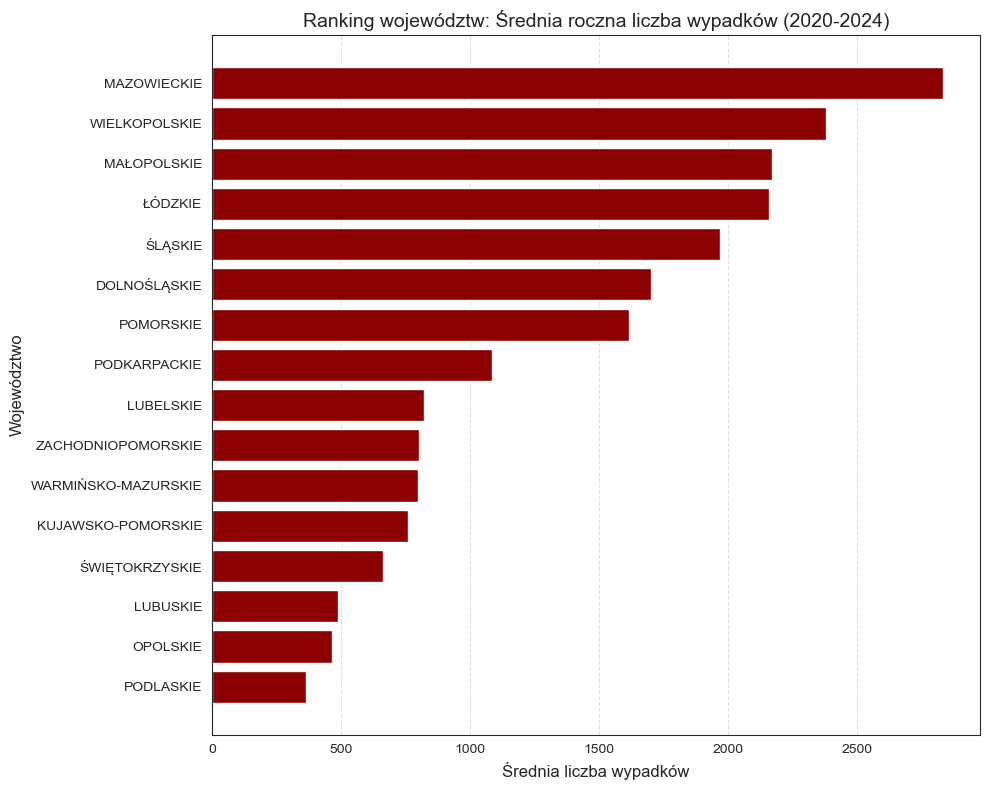

In [68]:
import matplotlib.pyplot as plt

wykres_data = df_srednie.sort_values(by='ogółem', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(wykres_data['Nazwa'], wykres_data['ogółem'], color='darkred')
plt.title('Ranking województw: Średnia roczna liczba wypadków (2020-2024)', fontsize=14)
plt.xlabel('Średnia liczba wypadków', fontsize=12)
plt.ylabel('Województwo', fontsize=12)

#siatka pomocnicza
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Powyższy wykres przedstawia ranking województw według średniej rocznej liczby wypadków w latach 2020-2024. Tak jak zostało to już omówione wyżej, najwięcej wypadków występuje w województwie mazowieckim, natomiast najmniejsze wartości notuje województwo podlaskie. Wykres ten jednoznacznie wskazuje na to, że bardziej zurbanizowane województwa mają wyższe średnie liczby wypadków.

In [69]:
wybrana_kat = 'wina pieszych - nieostrożne wejście na jezdnię' 

analiza_woj_piesi = []
df_tylko_woj = df[df['Nazwa'] != 'POLSKA']

for _, row in df_tylko_woj.iterrows():
    lata_kolumny = [f"{wybrana_kat}_{rok}" for rok in range(2020, 2025)]
    dane_seria = row[lata_kolumny].astype(float)
    
    analiza_woj_piesi.append({
        'Województwo': row['Nazwa'],
        'Średnia': dane_seria.mean(),
        'Mediana': dane_seria.median(),
        'Odch. std.': dane_seria.std(),
        'IQR': dane_seria.quantile(0.75) - dane_seria.quantile(0.25),
        'Skośność': dane_seria.skew(),
        'Kurtoza': dane_seria.kurtosis()
    })

ranking_woj_piesi = pd.DataFrame(analiza_woj_piesi).round(3)

ranking_woj_piesi = ranking_woj_piesi.sort_values(by='Średnia', ascending=False)

In [70]:
print(f"STATYSTYKI CZASOWE (2020-2024) DLA: {wybrana_kat.upper()}")
ranking_woj_piesi

STATYSTYKI CZASOWE (2020-2024) DLA: WINA PIESZYCH - NIEOSTROŻNE WEJŚCIE NA JEZDNIĘ


,Województwo,Średnia,Mediana,Odch. std.,IQR,Skośność,Kurtoza
6,MAZOWIECKIE,84.2,83.0,11.100,10.0,1.228,1.532
11,ŚLĄSKIE,83.0,77.0,22.057,17.0,0.696,0.740
5,MAŁOPOLSKIE,81.4,77.0,17.869,13.0,1.190,1.711
4,ŁÓDZKIE,66.6,72.0,17.358,25.0,0.072,-1.838
14,WIELKOPOLSKIE,59.4,58.0,6.025,6.0,1.226,1.229
0,DOLNOŚLĄSKIE,52.2,49.0,6.907,7.0,1.184,0.548
10,POMORSKIE,49.4,45.0,13.502,11.0,1.609,2.560
8,PODKARPACKIE,44.2,46.0,13.065,1.0,-1.168,2.727
2,LUBELSKIE,36.0,35.0,6.782,6.0,1.322,1.785
1,KUJAWSKO-POMORSKIE,27.6,28.0,4.037,3.0,-0.123,0.676


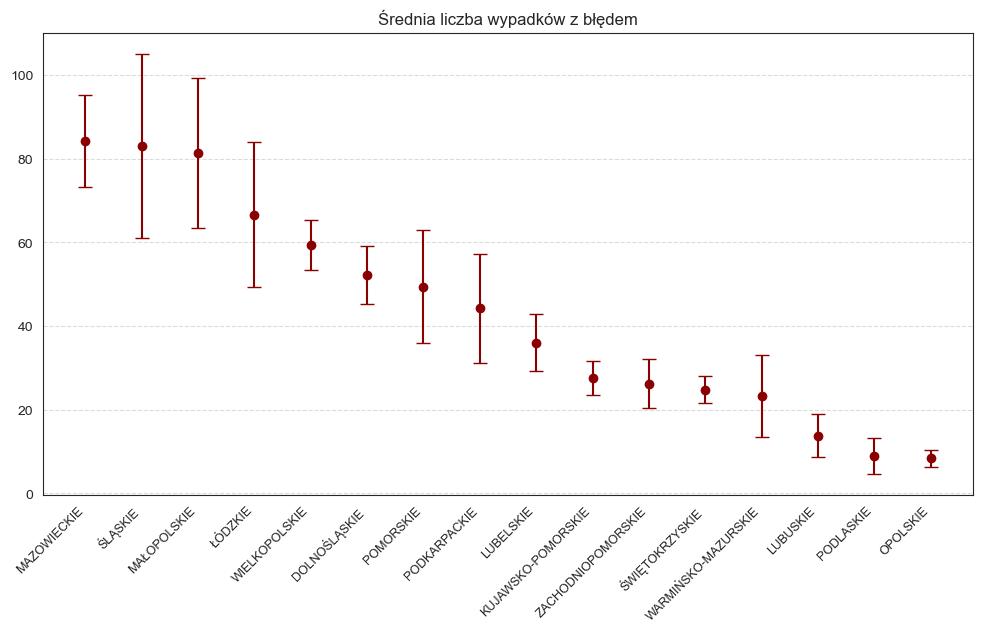

In [71]:
plt.figure(figsize=(12, 6))
plt.errorbar(ranking_woj_piesi['Województwo'], ranking_woj_piesi['Średnia'], 
             yerr=ranking_woj_piesi['Odch. std.'], fmt='o', color='darkred', capsize=5)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Średnia liczba wypadków z błędem')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Wykres przedstawia średnią liczbę wypadków z winy pieszych - nieostrożne wejście na jezdnię wraz z błędem. Największe przedziały błędu widoczne są dla województw śląskiego, małopolskiego oraz łódzkiego, co wskazuje na większe wahania liczby wypadków w czasie. Województwa z najniższą średnią charakteryzują się niewielką zmiennością.

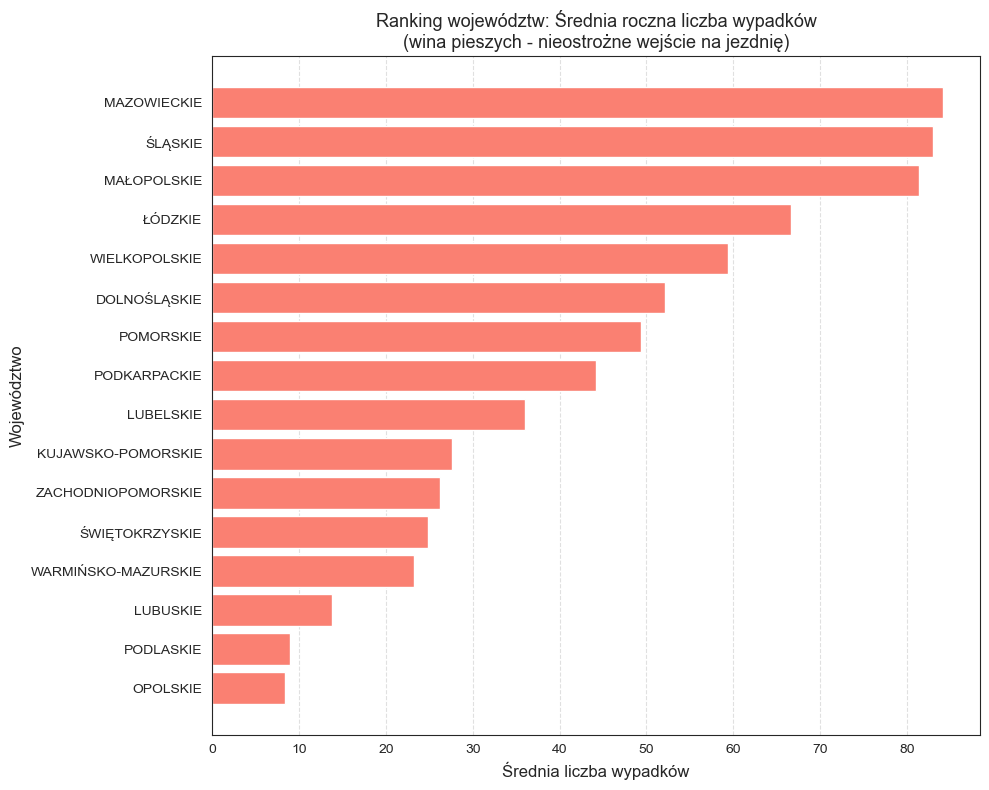

In [72]:
wykres_piesi = ranking_woj_piesi.sort_values(by='Średnia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(wykres_piesi['Województwo'], wykres_piesi['Średnia'], color='salmon')
plt.title(f'Ranking województw: Średnia roczna liczba wypadków\n({wybrana_kat})', fontsize=13)
plt.xlabel('Średnia liczba wypadków', fontsize=12)
plt.ylabel('Województwo', fontsize=12)

#siatka pomocnicza
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Porównanie wina kierowców i wina pieszych (ogółem)')

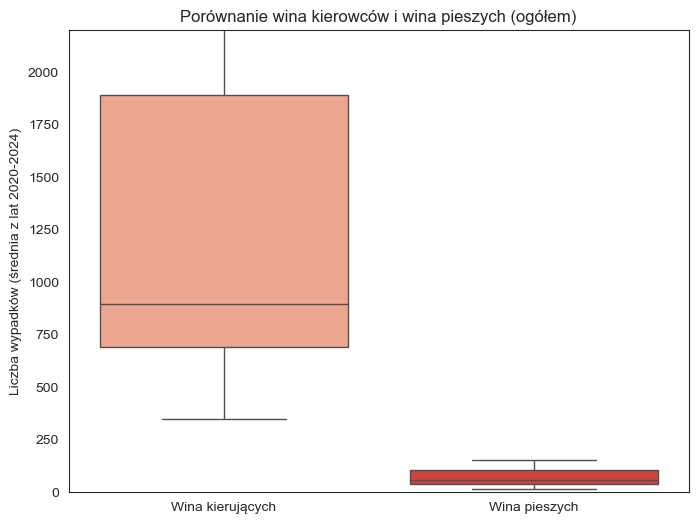

In [73]:
import seaborn as sns

df_boxplot = df_srednie[['wina kierujących pojazdami - ogółem',
                           'wina pieszych - ogółem']]

plt.figure(figsize=(8,6))

# Boxplot - pokazuje rozkład wartości
sns.boxplot(data=df_boxplot,palette="Reds")
plt.xticks([0, 1], ['Wina kierujących', 'Wina pieszych'])
plt.ylim(0,2200)
plt.ylabel("Liczba wypadków (średnia z lat 2020-2024)")
plt.title("Porównanie wina kierowców i wina pieszych (ogółem)")

Boxplot pokazuje, że zdecydowana większość wypadków przypisana jest winie kierujących, zarówno pod względem mediany, jak i rozrzutu danych. Wina kierowców charakteryzuje się bardzo dużą zmiennością między województwami,natomiast wypadki z winy pieszych są wielokrotnie mniej liczne i mają niewielki rozrzut, co potwierdza ich marginalny udział w ogólnej liczbie wypadków.

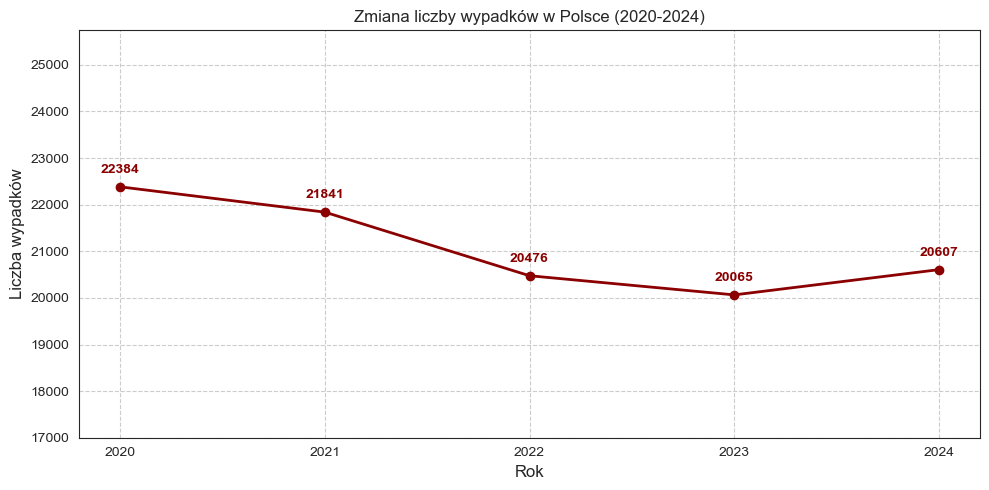

In [74]:
lata = [2020, 2021, 2022, 2023, 2024]
polska_ogolem = df[df['Nazwa'] == 'POLSKA'][[f'ogółem_{r}' for r in lata]].values.flatten()

plt.figure(figsize=(10, 5))
plt.plot(lata, polska_ogolem, marker='o', color='darkred', linewidth=2)

for i, txt in enumerate(polska_ogolem):
    plt.annotate(f'{int(txt)}', 
                 (lata[i], polska_ogolem[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10), #Przesunięcie napisu 10 pkt nad punkt
                 ha='center', 
                 fontweight='bold',
                 color='darkred')
plt.xticks(lata)    
plt.ylim(17000, max(polska_ogolem) * 1.15)
plt.title('Zmiana liczby wypadków w Polsce (2020-2024)')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Liczba wypadków', fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Analiza trendu zmian liczby wypadków w Polsce w latach 2020-2024 wskazuje na wyraźną tendencję spadkową, która dominowała przez większość badanego okresu, prowadząc do sukcesywnej redukcji zdarzeń z poziomu wyjściowego 22 384 w 2020 roku do minimum w badanym okresie, 20 065 w roku 2023. W kolejnym roku nastąpiło jednak odwrócenie trendu i wystąpił wzrost liczby wypadków do poziomu 20 607. Mimo ostatniego roku, ogólny bilans pięciolecia pozostaje dodatni – w porównaniu do początku okresu, liczba zdarzeń drogowych spadła.

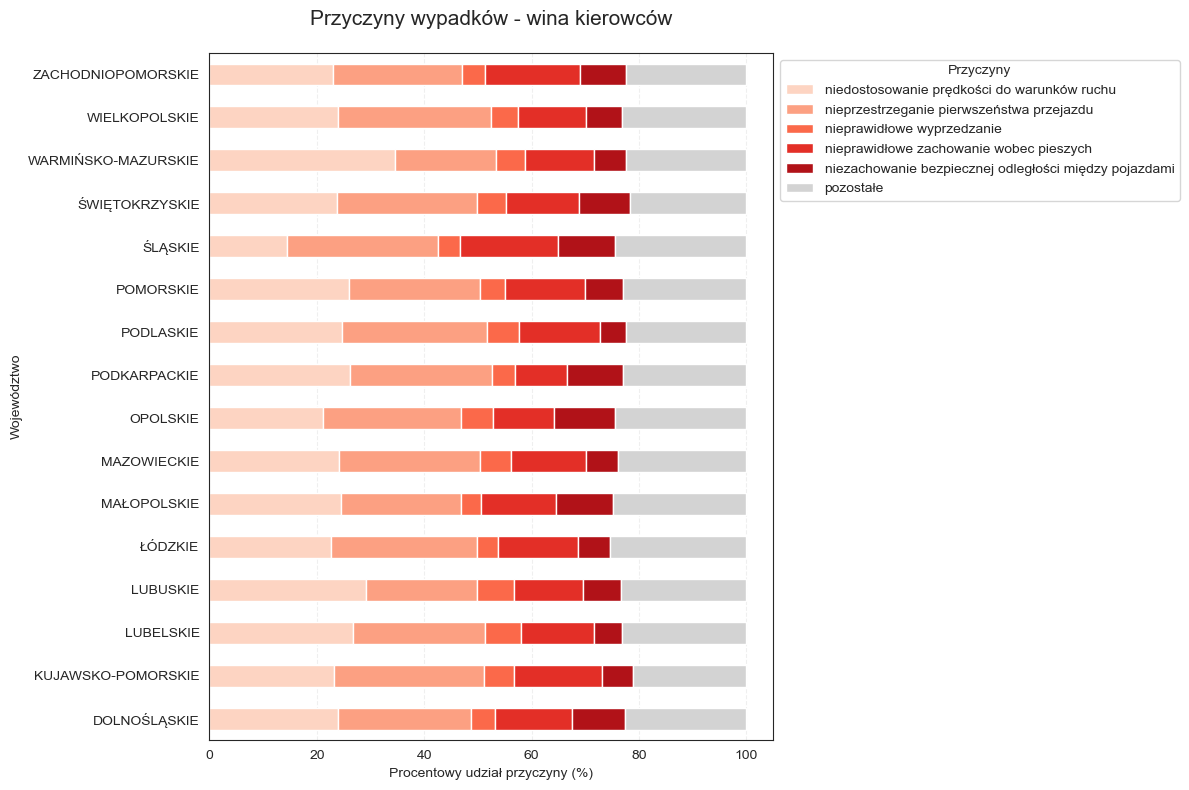

In [75]:
import seaborn as sns

przyczyny_cols = [
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe wyprzedzanie',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami',
    'wina kierujących pojazdami - pozostałe'
]


#przeliczanie na procenty, zeby uzyskac sume 100%
df_przyczyny = df_srednie[df_srednie['Nazwa'] != 'POLSKA'].set_index('Nazwa')[przyczyny_cols]
df_przyczyny = df_przyczyny.div(df_przyczyny.sum(axis=1), axis=0) * 100

custom_colors = list(sns.color_palette("Reds", n_colors=5))
custom_colors.append('lightgrey')
ax = df_przyczyny.plot(kind='barh', stacked=True, figsize=(12, 8), color=custom_colors)

plt.title('Przyczyny wypadków - wina kierowców', fontsize=15, pad=20)
plt.xlabel('Procentowy udział przyczyny (%)')
plt.ylabel('Województwo')
plt.legend(title='Przyczyny', bbox_to_anchor=(1, 1), loc='upper left',

           labels=[c.split(' - ')[-1] for c in przyczyny_cols])

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Wykres przedstawia proporcje przyczyn wypadków z winy kierowcy w Polsce w badanych latach. We wszystkich województwach dominującymi przyczynami wypadków z winy kierowców są niedostosowanie prędkości do warunków ruchu oraz nieprzestrzeganie pierwszeństwa przejazdu, które łącznie stanowią niemalże 50% wszystkich wypadków z winy kierowcy. Z kolei najmniejszy udział stanowi nieprawidłowe wyprzedanie. Struktura przyczyn jest podobna we wszysztkich województwach.

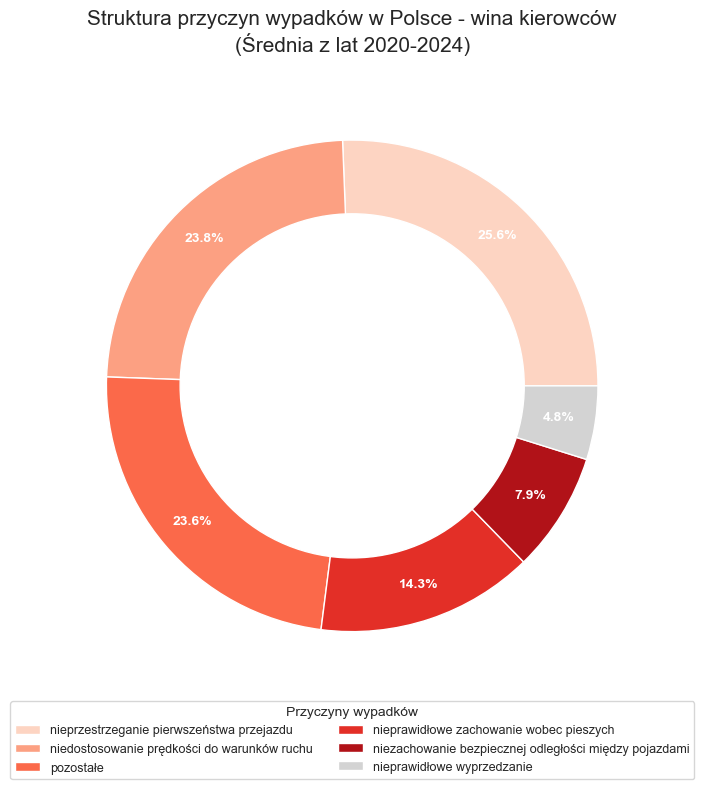

In [76]:
dane_polska = df_srednie[df_srednie['Nazwa'] != 'POLSKA'][przyczyny_cols].sum()

#sortowanie
dane_polska = dane_polska.sort_values(ascending=False)
labels_posortowane = [c.split(' - ')[-1] for c in dane_polska.index]

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    dane_polska, 
    autopct='%1.1f%%', 
    colors=custom_colors,
    pctdistance=0.85, #przesuniecie procentow blizej krawedzi
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.legend(
    wedges, labels_posortowane,
    title="Przyczyny wypadków",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=9
)
plt.setp(autotexts, size=10, weight="bold", color="white")

plt.title(f'Struktura przyczyn wypadków w Polsce - wina kierowców\n(Średnia z lat 2020-2024)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

Powyższy wykres przedstawia procentowy udział przyczyn wypadków z winy kierowców w lataach 2020-2024. Największy odsetek wypadków jest spowodowanych nieprzestrzeganiem pierszeństwa przejazdu oraz niedostosowaniem prędkości do warunków ruchu, natomiast najmniejszy nieprawidłowym wyprzedzaniem. Kategoria pozostałe również stanowi wysoki odsetek wypadków; uwzględnia ona wszelkie inne wypadki, które nie zostały wymienione w przyczynach wypadków.

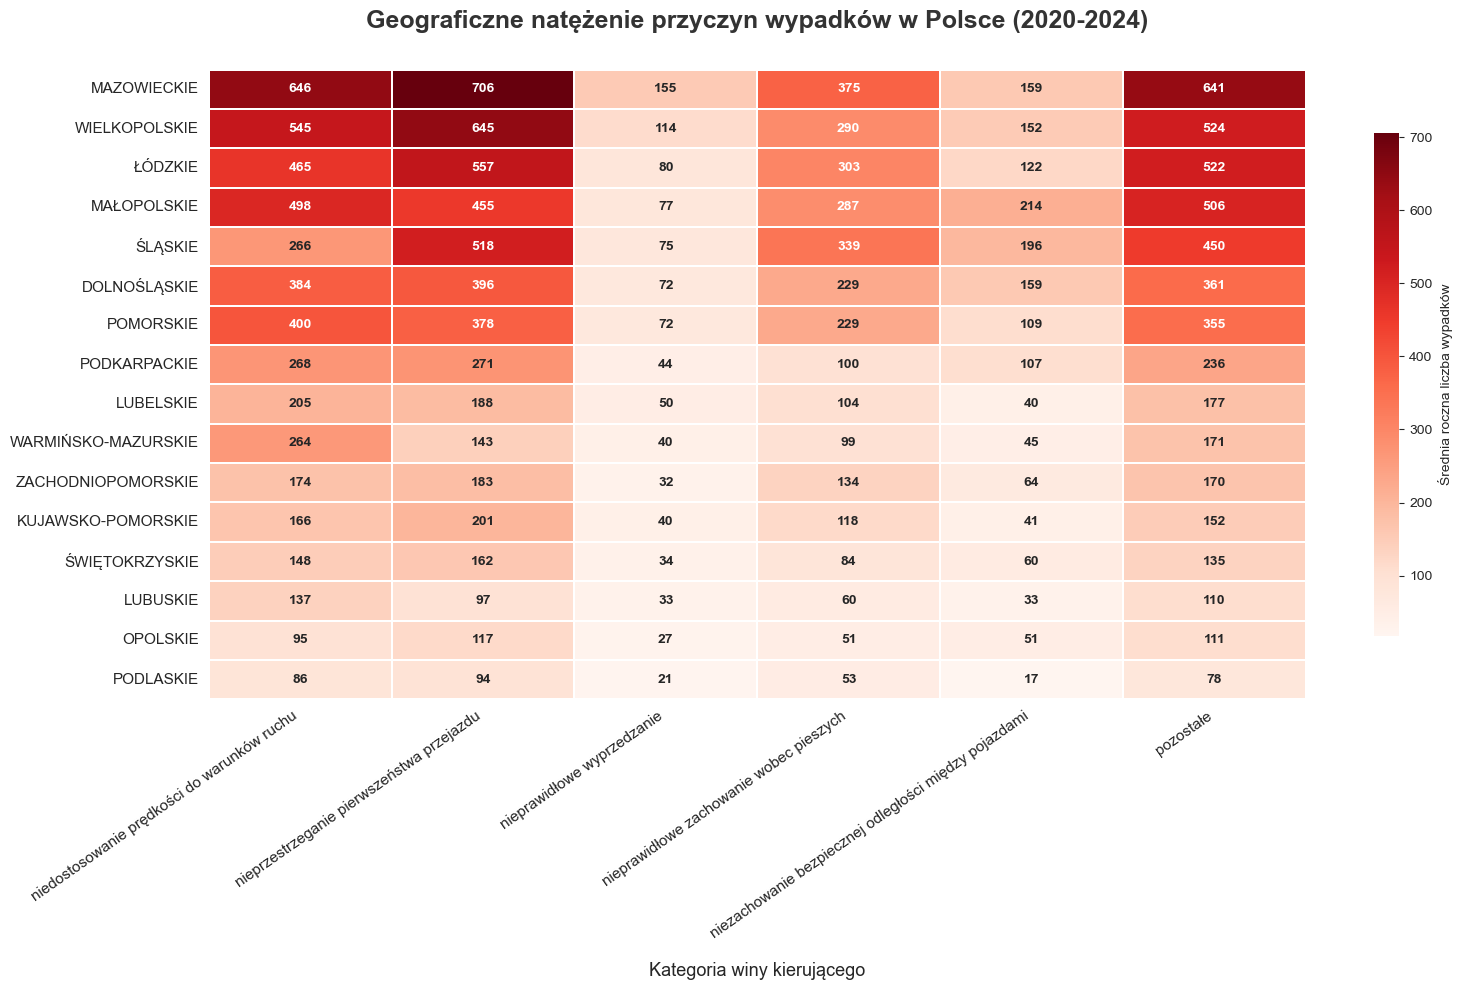

In [77]:
df_heatmap = df_srednie[df_srednie['Nazwa'] != 'POLSKA'].set_index('Nazwa')[przyczyny_cols]
df_heatmap.columns = [c.replace('wina kierujących pojazdami - ', '') for c in df_heatmap.columns]
df_heatmap = df_heatmap.apply(pd.to_numeric, errors='coerce')

df_heatmap['Suma'] = df_heatmap.sum(axis=1)
df_heatmap = df_heatmap.sort_values('Suma', ascending=False).drop('Suma', axis=1)

plt.figure(figsize=(16, 10))
sns.set_style("white")

ax = sns.heatmap(
    df_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=1.2,
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.8, "label": "Średnia roczna liczba wypadków"}
)
plt.title('Geograficzne natężenie przyczyn wypadków w Polsce (2020-2024)',
          fontsize=18, pad=30, fontweight='bold', color='#333333')
plt.xlabel('Kategoria winy kierującego', fontsize=13, labelpad=15)
plt.ylabel('', fontsize=13)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Powyższy wykres ponownie wskazuje, że największe natężenie wypadków z winy kierowców występuje w województwach o dużej liczbie mieszkańców i natężeniu ruchu, oraz potwierdza główne przyczyny wypadków, wraz z ich czętotliwością. Wykres ten bardzo konkretnie oddziela najczęstsze przyczyny i ich regiony, wskazując bezpośrednio na najbezpieczniejsze województwa.

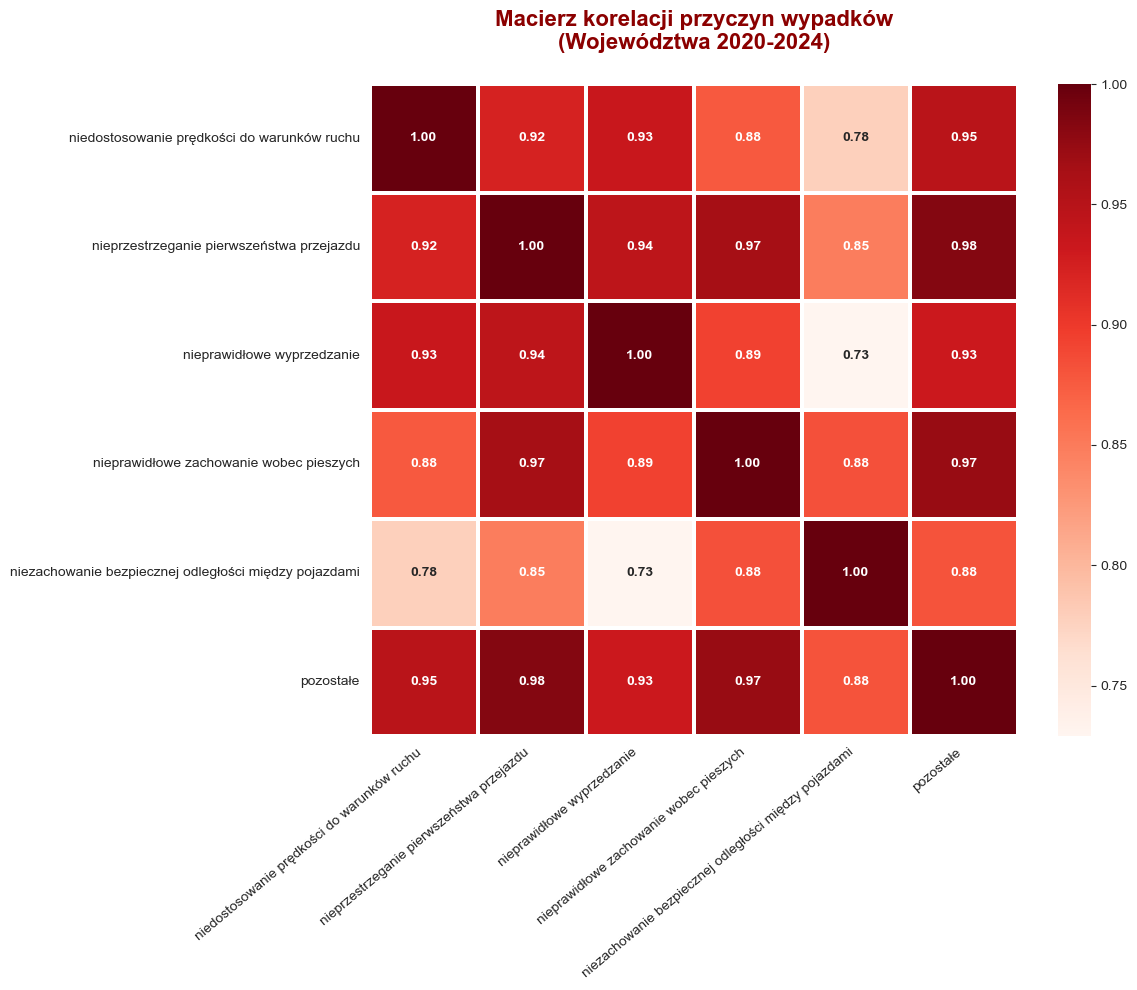

In [78]:
df_corr = df_srednie[df_srednie['Nazwa'] != 'POLSKA'][przyczyny_cols]
df_corr.columns = [c.replace('wina kierujących pojazdami - ', '') for c in df_corr.columns]
corr_matrix = df_corr.corr()
plt.figure(figsize=(12, 10))
sns.set_style("white")

sns.heatmap(
    corr_matrix, 
    annot=True, #wspolczynniki 0.0 - 1.0
    fmt=".2f", 
    cmap="Reds", 
    linewidths=1.5, 
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title('Macierz korelacji przyczyn wypadków\n(Województwa 2020-2024)', 
          fontsize=16, pad=25, fontweight='bold', color='darkred')

plt.xticks(rotation=40, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


Macierz korelacji pokazuje bardzo silne dodatnie zależności między wszystkimi analizowanymi przyczynami wypadków w województwach w latach 2020–2024, co oznacza, że regiony z wysoką liczbą wypadków w jednej kategorii zwykle notują także wysokie wartości w pozostałych. Najsilniejsze korelacje występują między nieprzestrzeganiem pierwszeństwa przejazdu oraz nieprawidłowym zachowaniem wobec pieszych, natomiast relatywnie najsłabsza, choć nadal wysoka zależność dotyczy niezachowania bezpiecznej odległości między pojazdami i nieprawidłowego wyprzedzania. 